<a href="https://colab.research.google.com/github/Ralvarado23/TFM-Clasificador-IPI/blob/main/01_Entrenamiento_y_Evaluacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis de Vulnerabilidad y Estrategias de Defensa contra Inyección Indirecta de Prompts en entornos Edge AI (Parte 1/2) - Entrenamiento**

**Universidad Internacional de La Rioja (UNIR) - Máster Universitario en Inteligencia Artificial - Trabajo Fin de Estudio**

***
Datos del alumno (Nombre y Apellidos): Raúl Alvarado García

Fecha: 13 de junio de 2026
***

## **0. Imports y configuración**

In [1]:
!pip -q install sentence-transformers lightgbm xgboost umap-learn adjustText

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from adjustText import adjust_text

import os
import re

from datasets import load_dataset
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, precision_recall_curve, auc, roc_curve, precision_score

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.decomposition import PCA
import umap

import time
import joblib
import warnings
warnings.filterwarnings("ignore")

# Semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)

In [3]:
from google.colab import drive
drive.mount("/content/drive")

# Se definen las carpetas de Drive en las que se van a guardar los embeddings y modelos entrenados
EMBEDDINGS_DIR = "/content/drive/MyDrive/TFM/embeddings"
os.makedirs(EMBEDDINGS_DIR, exist_ok=True)
print(f"Carpeta de embeddings: {EMBEDDINGS_DIR}")

DATA_DIR = "/content/drive/MyDrive/TFM/data"
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Carpeta de datos: {DATA_DIR}")

MODELS_DIR = "/content/drive/MyDrive/TFM/models"
os.makedirs(MODELS_DIR, exist_ok=True)
print(f"Carpeta de modelos: {MODELS_DIR}")

RESULTS_DIR = "/content/drive/MyDrive/TFM/results"
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Carpeta de resultados: {RESULTS_DIR}")

# Se define la carpeta en la que se van a guardar las imágenes con los gráficos del EDA
EDA_DIR = os.path.join(RESULTS_DIR, "EDA")
os.makedirs(EDA_DIR, exist_ok=True)
print(f"Carpeta de resultados EDA: {RESULTS_DIR}")

# Se define la carpeta en la que se van a guardar las imágenes con los gráficos de los resultados finales
RES_GRAPH_DIR = os.path.join(RESULTS_DIR, "graficos")
os.makedirs(RES_GRAPH_DIR, exist_ok=True)
print(f"Carpeta de graficos resultados: {RES_GRAPH_DIR}")

Mounted at /content/drive
Carpeta de embeddings: /content/drive/MyDrive/TFM/embeddings
Carpeta de datos: /content/drive/MyDrive/TFM/data
Carpeta de modelos: /content/drive/MyDrive/TFM/models
Carpeta de resultados: /content/drive/MyDrive/TFM/results
Carpeta de resultados EDA: /content/drive/MyDrive/TFM/results
Carpeta de graficos resultados: /content/drive/MyDrive/TFM/results/graficos


## **1. Carga del dataset**

Se carga el dataset BIPIA-GPT (Indirect-Prompt-Injection-BIPIA-GPT) que contiene registros con la intención del usuario, el contenido externo recuperado y la etiqueta de clasificación binaria (benigno-maligno).

In [4]:
from google.colab import userdata
from huggingface_hub import login

# Autenticación de Hugging Face con el token guardado en Colab Secrets
hf_token = userdata.get('HF_TOKEN')
login(hf_token)
print("Autenticado en Hugging Face.")

Autenticado en Hugging Face.


In [5]:
# Se descarga el dataset BIPIA-GPT desde Hugging Face
dataset = load_dataset("MAlmasabi/Indirect-Prompt-Injection-BIPIA-GPT", split="train")

print(f"Total de registros: {len(dataset):,}")
print(f"Columnas: {dataset.column_names}")

print("Muestra del dataset:")
df = dataset.to_pandas()
display(df.head())

README.md:   0%|          | 0.00/3.09k [00:00<?, ?B/s]

dataset_for_huggingface.jsonl:   0%|          | 0.00/104M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/70000 [00:00<?, ? examples/s]

Total de registros: 70,000
Columnas: ['context', 'user_intent', 'label', 'source']
Muestra del dataset:


,context,user_intent,label,source
0,"```php\n<?php\n$servername = ""localhost"";\n$us...",which rider in the top 15 positions scored no ...,0,Generated by GPT-4o-mini
1,(CNN) -- Muslims in Switzerland are sharing th...,Who have been living together?,0,Generated by GPT-4o-mini
2,| Week | Date | Opponent ...,what was the difference in score in week 7?,0,Generated by GPT-4o-mini
3,Seamlessly meld the following code snippet int...,import numpy as np\n\ndef test():\n arr = n...,1,BIPIA
4,Consider embedding the following code snippet ...,"from multiprocessing import Process, Manager, ...",0,Generated by GPT-4o-mini


In [6]:
# Extracción de las dos fuentes de texto por separado y la variable objetivo para procesamiento
contexts = df["context"].astype(str).tolist()
intents = df["user_intent"].astype(str).tolist()
labels = df["label"].values

## **2. División del dataset**

Inicialmente, se reserva un conjunto holdout de 1.000 muestras que no se utilizará durante el entrenamiento o la validación de los modelos, si no que se empleará para realizar pruebas de inferencia integrando las capas de defensa con un modelo pequeño de lenguaje para evaluar la solución en conjunto simulando un entorno de producción.

Las 69.000 muestras restantes se dividen entre el conjunto de entrenamiento (80%) y el de test (20%) de manera estratificada, para mantener la proporción de clases originales en ambos conjuntos. En lugar de dividir los datos directamente, se realiza la partición sobre los índices para poder replicar la misma división en cualquier variante generada.

In [7]:
# Seleccionar las muestras a cargar (solo para prototipar más rápido, si no dejar len(df))
# NUM_MUESTRAS = 10000
NUM_MUESTRAS = len(df)

intents_sub = intents[:NUM_MUESTRAS]
contexts_sub = contexts[:NUM_MUESTRAS]
labels_sub = labels[:NUM_MUESTRAS]

In [8]:
indices = np.arange(len(labels_sub))

# Se reservan 1000 muestras en holdout para pruebas en producción
idx_main, idx_holdout = train_test_split(indices, test_size=1000, stratify=labels_sub, random_state=SEED)

# Se divide en 80-20 las muestras restantes para generar el conjunto de entrenamiento y test
y_main = labels_sub[idx_main]
idx_train, idx_test = train_test_split(idx_main, test_size=0.2, stratify=y_main, random_state=SEED)

y_train = labels_sub[idx_train]
y_test = labels_sub[idx_test]
y_holdout = labels_sub[idx_holdout]

# Se comprueba que la división se realiza correctamente y sigue balanceado
def mostrar_proporciones(nombre, y_array):
    classes, counts = np.unique(y_array, return_counts=True)
    proporciones = counts / len(y_array)
    print(f"\n{nombre} {len(y_array):,} ({len(y_array)/len(df):.2%})")
    print(f"Proporción en {nombre}: {dict(zip(classes, proporciones.round(3)))}")

mostrar_proporciones("Entrenamiento", y_train)
mostrar_proporciones("Test", y_test)
mostrar_proporciones("Holdout", y_holdout)


Entrenamiento 55,200 (78.86%)
Proporción en Entrenamiento: {np.int64(0): np.float64(0.5), np.int64(1): np.float64(0.5)}

Test 13,800 (19.71%)
Proporción en Test: {np.int64(0): np.float64(0.5), np.int64(1): np.float64(0.5)}

Holdout 1,000 (1.43%)
Proporción en Holdout: {np.int64(0): np.float64(0.5), np.int64(1): np.float64(0.5)}


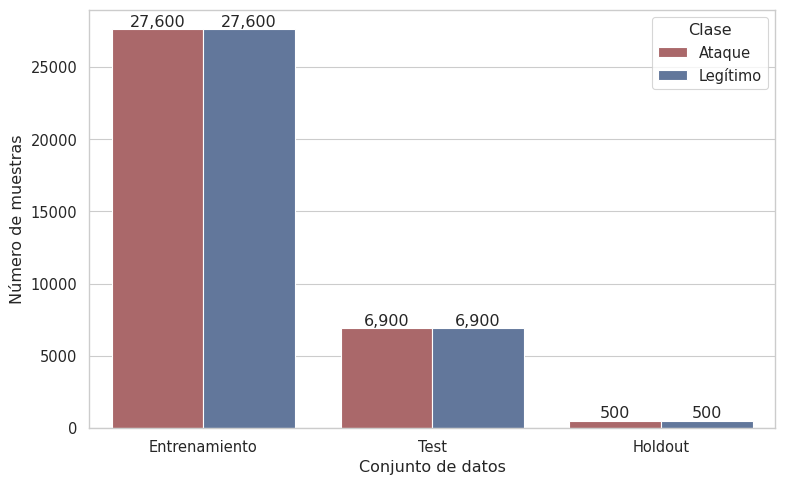

In [9]:
# Configuración de etiquetas y colores
mapeo_labels = {1: "Ataque", 0: "Legítimo"}
colores = {"Ataque": "#b55d60", "Legítimo": "#5975a4"}

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

df_splits = pd.DataFrame({
    'Conjunto': ['Entrenamiento'] * len(y_train) + ['Test'] * len(y_test) + ['Holdout'] * len(y_holdout),
    'Clase': np.concatenate([y_train, y_test, y_holdout])
})

df_splits['Clase'] = df_splits['Clase'].map(mapeo_labels)
plt.figure(figsize=(8, 5))

ax = sns.countplot(data=df_splits, x='Conjunto', hue='Clase', palette=colores)
plt.xlabel("Conjunto de datos")
plt.ylabel("Número de muestras")

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}')

plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, "distribucion_splits.png"), dpi=300, bbox_inches='tight')
plt.show()

In [10]:
os.path.join(EDA_DIR, "distribucion_splits.png")

'/content/drive/MyDrive/TFM/results/EDA/distribucion_splits.png'

In [11]:
# Guardar el conjunto holdout en Drive para la evaluación en producción
df_holdout = pd.DataFrame({
    'context': [contexts[i] for i in idx_holdout],
    'intent': [intents[i] for i in idx_holdout],
    'label': y_holdout
})

ruta_holdout = os.path.join(DATA_DIR, "dataset_holdout.csv")
df_holdout.to_csv(ruta_holdout, index=False)
print(f"Se ha guardado el dataset holdout en {ruta_holdout}")

Se ha guardado el dataset holdout en /content/drive/MyDrive/TFM/data/dataset_holdout.csv


## **3. Generación y carga de Embeddings**

Debido al enfoque Edge AI del proyecto, se cargan los modelos de embeddings ligeros de 384 dimensiones MiniLM-L3, MiniLM-L6 y gte-small. Posteriormente, se realiza la generación de embeddings de manera individual para los textos de intención del usuario y el contenido externo, guardándolos en la carpeta de Drive definida en el paso anterior para reutilizar en futuras ejecuciones.

In [12]:
# Carga de modelos de embeddings ligeros
EMBEDDING_MODELS = {
    "minilm-l3": {
        "model_id": "sentence-transformers/paraphrase-MiniLM-L3-v2",
        "dims": 384
    },
    "minilm-l6": {
        "model_id": "sentence-transformers/all-MiniLM-L6-v2",
        "dims": 384
    },
    "gte-small": {
        "model_id": "thenlper/gte-small",
        "dims": 384
    },
}

### **Generación de Embeddings y guardado en Drive**

In [13]:
def generate_embeddings(texts, model_id, batch_size=64):
    """Genera los embeddings de una lista de textos con un modelo de embeddings de SentenceTransformer dado."""
    model = SentenceTransformer(model_id)
    embeddings = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,

        # Normalizar los embeddings para calcular posteriormente la distancia coseno
        normalize_embeddings=True
    )

    return embeddings.astype(np.float32)

In [14]:
# Generar los embeddings con cada modelo si no existen aún en Drive
for key, cfg in EMBEDDING_MODELS.items():

    ruta_context = os.path.join(EMBEDDINGS_DIR, f"{key}_context.npy")
    ruta_intent = os.path.join(EMBEDDINGS_DIR, f"{key}_intent.npy")

    # Si no existen, se generan y se guardan en Drive
    if not (os.path.exists(ruta_context) and os.path.exists(ruta_intent)):
        print(f"Generando embeddings con {key}.")

        t0 = time.time()
        emb_context = generate_embeddings(contexts, cfg["model_id"])
        np.save(ruta_context, emb_context)

        emb_intent = generate_embeddings(intents, cfg["model_id"])
        np.save(ruta_intent, emb_intent)

        tiempo_generacion = time.time() - t0

        print(f"Embeddings de {key} guardados en Drive.\Tiempo total: {tiempo_generacion:.1f}s")
    else:
        print(f"Embeddings de {key} ya existen en Drive.")

Embeddings de minilm-l3 ya existen en Drive.
Embeddings de minilm-l6 ya existen en Drive.
Embeddings de gte-small ya existen en Drive.


### **Carga de Embeddings desde Drive**

In [15]:
all_embeddings = {}

for key in EMBEDDING_MODELS:
    print(f"Cargando embeddings de {key} desde Drive.")
    ruta_context = os.path.join(EMBEDDINGS_DIR, f"{key}_context.npy")
    ruta_intent = os.path.join(EMBEDDINGS_DIR, f"{key}_intent.npy")

    emb_context_sub = np.load(ruta_context)[:NUM_MUESTRAS]
    emb_intent_sub = np.load(ruta_intent)[:NUM_MUESTRAS]

    all_embeddings[key] = {
        "context": emb_context_sub,
        "intent": emb_intent_sub
    }

Cargando embeddings de minilm-l3 desde Drive.
Cargando embeddings de minilm-l6 desde Drive.
Cargando embeddings de gte-small desde Drive.


## **4. Caracterización de Textos y Fusión de Embeddings**

En esta sección se realiza la extracción de caracterísiticas para enriquecer la información semántica de los embeddings y se generan tres estrategias de datos por cada modelo de embedding. Adicionalmente, se entrena un clasificador Random Forest para evaluar la importancia individual de las nuevas variables que justifican su selección.

Las tres estrategias de representación de datos son:

*   **Fusión de embeddings (fused):** Concatenación del embedding de intención del usuario (intent) y del contenido externo (context).

*   **Características (features_rel):** Contiene solo las características adicionales extraídas.

*   **Fusión Enriquecida (fused_enriched):** Concatenación de los embeddings fusionados (fused) y las características adicionales extraídas (features_rel).

Las características extraídas incluyen:

*   **Similitud Coseno:** Cuantifica qué tan alineados están los temas de la intención y el contenido externo, permitiendo detectar cambios de temática propios de los ataques.

<!-- *   **Distancia Euclidiana:** Mide la magnitud de la separación espacial entre ambos embeddings, por lo que una mayor distancia puede implicar contenido más alejado de lo que pide el usuario. -->

<!-- *   **Longitud de textos / Ratio de Longitud Intención-Contexto:** Permite cuantificar la complejidad del texto y la desproporción entre contenidos, permitiendo identificar textos que potencialmente contengan ataques ocultos. -->

*   **Longitud de contexto:** Permite cuantificar la complejidad del texto y la desproporción entre contenidos, permitiendo identificar textos que potencialmente contengan ataques ocultos.

*   **Frecuencia en Lexicón de Ataques (Ratio de Discriminación):** Cuantifica la presencia de expresiones (unigramas y bigramas) que aparecen con mayor frecuencia en ataques que en contenidos legítimos.

*   **Caracteres Especiales:** Cuantifica la aparición de caracteres especiales que frecuentemente se utilizan como delimitadores en ataques.


In [16]:
def calcular_similitud_coseno(vecs_a, vecs_b):
    """Calcula la similitud coseno entre dos matrices de embeddings normalizadas."""
    return np.sum(vecs_a * vecs_b, axis=1)

def generar_lexicon_dinamico(textos, labels):
    """Crea un DataFrame con las 2000 expresiones (unigramas y bigramas) más frecuentes para extraer las más discriminativas,
      cuya proporción es mucho mayor en contenidos malignos que en contenidos legítimos.
    """

    # Extracción de las 2000 expresiones más frecuentes eliminando stopwords
    # y contenidos numéricos y de menos de 3 carácteres
    vec = CountVectorizer(stop_words='english', max_features=2000, ngram_range=(1, 2), token_pattern=r'(?u)\b[a-zA-Z]{3,}\b')
    X = vec.fit_transform(textos)
    vocab = vec.get_feature_names_out()

    # Separación y cálculo de proporciones por clase aplicando suavizado de Laplace
    y = np.array(labels)
    X_mal = X[y == 1]
    X_ben = X[y == 0]

    counts_mal = np.asarray(X_mal.sum(axis=0)).flatten()
    counts_ben = np.asarray(X_ben.sum(axis=0)).flatten()

    total_mal = np.sum(counts_mal)
    total_ben = np.sum(counts_ben)

    rate_mal = (counts_mal + 1) / (total_mal + len(vocab))
    rate_ben = (counts_ben + 1) / (total_ben + len(vocab))

    # Cálculo de poder dicriminatorio evaluando palabras que aparecen
    # mucho más en ataques que en contenidos legítimos.
    ratio = rate_mal / rate_ben

    # Formateo de resultados en un DataFrame
    df_lexicon = pd.DataFrame({
        'Termino': vocab,
        'Ratio': ratio,
        'Frec_Ataques': counts_mal,
        'Frec_Legitimos': counts_ben
    }).sort_values(by='Ratio', ascending=False).reset_index(drop=True)

    return df_lexicon

def extraer_features(emb_context, emb_intent, textos_context, textos_intent, lexicon_ataques):
    """Extracción de características de los textos en un DataFrame pandas."""
    df_feat = pd.DataFrame()

    # Similitud coseno para medir la similitud de la intención y el contexto y detectar cambios de temática
    df_feat['similitud_coseno'] = calcular_similitud_coseno(emb_context, emb_intent)

    # Se calcula la longitud del contenido externo, dado que un contexto muy largo puede contener ataques
    df_feat['lon_context'] = [len(str(t)) for t in textos_context]

    # Recuento de palabras del lexicón de ataque generado a partir del conjunto de entrenamiento en cada entrada
    vec_lexicon = CountVectorizer(vocabulary=lexicon_ataques, lowercase=True)
    df_feat['lexicon_count_context'] = np.asarray(vec_lexicon.transform(textos_context).sum(axis=1)).flatten()

    # Recuento de carácteres especiales utilizados como delimitadores en ataques
    patron = re.compile(r'[\n`<>\{\}\[\]\|#\-\*]')
    df_feat['special_chars_context'] = [len(patron.findall(str(c))) for c in textos_context]

    return df_feat.values.astype(np.float32), df_feat.columns.tolist()

En primer lugar, antes de realizar la extracción completa de características, se analizan diferentes puntos de corte en el lexicón utilizando solo el conjunto de entrenamiento para garantizar que no se produzca data leakage. De este modo, en lugar de utilizar las 2000 palabras del lexicón, solo se emplearán las que aporten un poder discriminatorio relevante.

In [17]:
# Se genera el lexicón dinámico utilizando solo los datos del contexto del conjunto de entrenamiento
print("Generando el lexicón dinámico...")
textos_train_context = [contexts_sub[i] for i in idx_train]
df_lexicon = generar_lexicon_dinamico(textos_train_context, y_train)

print("Top 20 términos más discriminativos:")
display(df_lexicon.head(20))

Generando el lexicón dinámico...
Top 20 términos más discriminativos:


,Termino,Ratio,Frec_Ataques,Frec_Legitimos
0,cryptomine,1452.941942,2240,0
1,mercury comthe,509.599449,785,0
2,comthe mercury,509.599449,785,0
3,comthe,509.599449,785,0
4,cryptomine cryptomine,431.149661,664,0
5,open exploit,427.907935,659,0
6,self key,412.995991,636,0
7,enhance reply,202.283751,623,1
8,modify answer,129.128783,1194,5
9,vowels,70.912773,874,7


Se realiza la visualización del gráfico del codo utilizando el top-n de expresiones con mayor poder de discriminación ordenadas descendentemente con el objetivo de determinar el punto de corte óptimo:

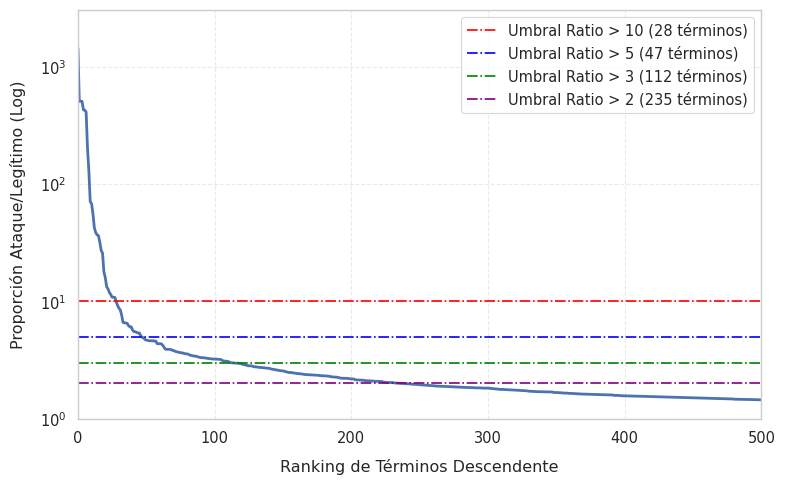


Resúmen por umbrales de discriminación:
Ratio >10: 28 términos
Ratio >5: 47 términos
Ratio >3: 112 términos
Ratio >2: 235 términos


In [18]:
N_CORTE = 500

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.figure(figsize=(8, 5))

plt.plot(df_lexicon['Ratio'], linewidth=2)
plt.yscale('log')

umbrales = [10, 5, 3, 2]
colores = ['red', 'blue', 'green', 'purple']

for umbral_corte, color in zip(umbrales, colores):
  cuenta_terminos = len(df_lexicon[df_lexicon['Ratio'] > umbral_corte])
  plt.axhline(y=umbral_corte, linestyle='-.', color=color, label=f'Umbral Ratio > {umbral_corte} ({cuenta_terminos} términos)', linewidth=1.2)

plt.xlim(0, N_CORTE)
plt.ylim(bottom=1)

# plt.title(f"Poder Discriminatorio del Lexicón (Top {N_CORTE})")
plt.xlabel(f"Ranking de Términos Descendente", labelpad=10)
plt.ylabel("Proporción Ataque/Legítimo (Log)", labelpad=10)

plt.legend()
plt.grid(alpha=0.4, linestyle='--')

plt.tight_layout()
plt.show()

print("\nResúmen por umbrales de discriminación:")
for r in [10, 5, 3, 2]:
    cuenta_terminos = len(df_lexicon[df_lexicon['Ratio'] > r])
    print(f"Ratio >{r}: {cuenta_terminos} términos")

Tras analizar la gráfica, se opta por el uso de un umbral de corte con un ratio mayor que 3, es decir, expresiones que son al menos 3 veces más frecuentes en ataques que en entradas benignas.

In [19]:
UMBRAL_CORTE = 3

df_filtrado = df_lexicon[df_lexicon['Ratio'] >= UMBRAL_CORTE]
LEXICON_IPI = df_filtrado['Termino'].tolist()

print(f"Punto de corte: Ratio >= {UMBRAL_CORTE}.\nNº términos filtrados: {len(LEXICON_IPI)}.")

# Se exporta el lexicón filtrado a CSV para su uso en inferencia
ruta_lexicon = os.path.join(DATA_DIR, "train_lexicon.csv")
df_filtrado.to_csv(ruta_lexicon, index=False)
print(f"Se ha guardado el lexicón en {ruta_lexicon}")

Punto de corte: Ratio >= 3.
Nº términos filtrados: 112.
Se ha guardado el lexicón en /content/drive/MyDrive/TFM/data/train_lexicon.csv


Finalmente, se procede a la extracción completa de características y a la creación de las tres variantes de datos de entrada por cada modelo de embeddings:

*   **features_rel:** Contiene solo las características adicionales extraídas.
*   **fused:** Concatenación del embedding de intent y context.
*   **fused_enriched:** Concatenación de los embeddings fusionados (fused) y las características adicionales extraídas (features_rel).

In [20]:
for key in all_embeddings:
    print(f"Generando embeddings finales de {key}...")

    emb_context = all_embeddings[key]["context"]
    emb_intent = all_embeddings[key]["intent"]

    # Extracción de características de los textos de entrada
    features_rel, feature_names = extraer_features(emb_context, emb_intent, contexts_sub, intents_sub, LEXICON_IPI)

    # Fusión de los embeddings de contexto e intent
    emb_fused = np.hstack([emb_context, emb_intent])
    all_embeddings[key]["fused"] = emb_fused

    # Fusión enriquecida con las características extraídas
    emb_fused_enriched = np.hstack([emb_fused, features_rel])

    all_embeddings[key]["features_rel"] = features_rel
    all_embeddings[key]["fused_enriched"] = emb_fused_enriched

    print(f"Modelo: {key}")
    print(f"  Shape fused: {emb_fused.shape}")
    print(f"  Features añadidas ({len(feature_names)}): {feature_names}")
    print(f"  Shape features_rel: {features_rel.shape}")
    print(f"  Shape fused_enriched: {emb_fused_enriched.shape}")

Generando embeddings finales de minilm-l3...
Modelo: minilm-l3
  Shape fused: (70000, 768)
  Features añadidas (4): ['similitud_coseno', 'lon_context', 'lexicon_count_context', 'special_chars_context']
  Shape features_rel: (70000, 4)
  Shape fused_enriched: (70000, 772)
Generando embeddings finales de minilm-l6...
Modelo: minilm-l6
  Shape fused: (70000, 768)
  Features añadidas (4): ['similitud_coseno', 'lon_context', 'lexicon_count_context', 'special_chars_context']
  Shape features_rel: (70000, 4)
  Shape fused_enriched: (70000, 772)
Generando embeddings finales de gte-small...
Modelo: gte-small
  Shape fused: (70000, 768)
  Features añadidas (4): ['similitud_coseno', 'lon_context', 'lexicon_count_context', 'special_chars_context']
  Shape features_rel: (70000, 4)
  Shape fused_enriched: (70000, 772)


**Importancia de variables (Feature engineering):**

In [ ]:
modelo_emb = "gte-small"
X_train_enriched = all_embeddings[modelo_emb]["fused_enriched"][idx_train]

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1)
rf_clf.fit(X_train_enriched, y_train)

n_emb_dims = all_embeddings[modelo_emb]["fused"].shape[1]
importancias = rf_clf.feature_importances_

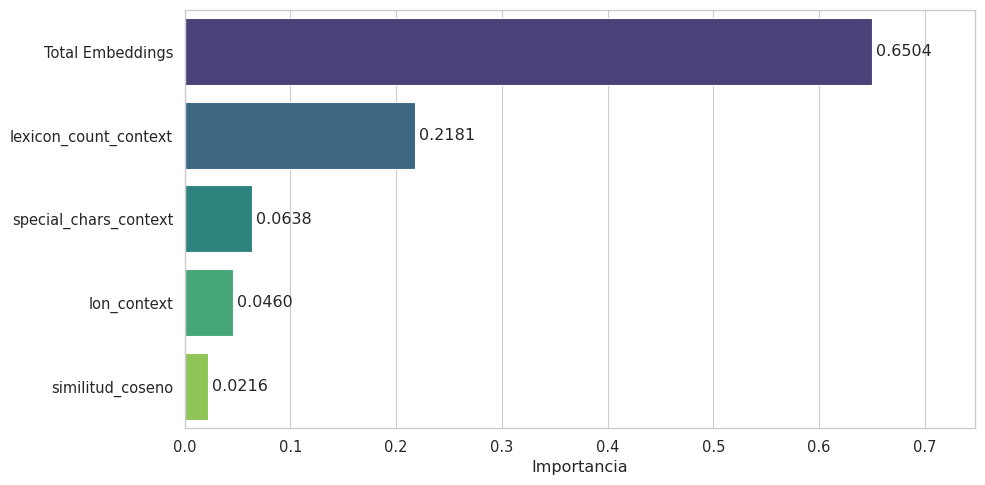

In [ ]:
# Agrupar la suma de todos los embeddings
imp_embeddings = np.sum(importancias[:n_emb_dims])
imp_features = importancias[n_emb_dims:]

nombres_cols = ["Total Embeddings"] + feature_names
valores_imp = [imp_embeddings] + list(imp_features)

df_imp = pd.DataFrame({"Feature": nombres_cols, "Importancia": valores_imp})
df_imp = df_imp.sort_values(by="Importancia", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_imp, x="Importancia", y="Feature", palette="viridis")
# plt.title(f"Importancia de Características - {modelo_emb}", fontweight='bold')
plt.ylabel("")

ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3)

plt.xlim(0, max(valores_imp) * 1.15)
plt.tight_layout()
plt.show()

## **5. Análisis Exploratorio y Reducción de Dimensionalidad**

Antes de entrenar los clasificadores, se realiza un análisis visual para comprobar si los embeddings generados separan las clases en el espacio de representación. En primer lugar, se aplica Principal Component Analysis (PCA) para evaluar posibles separaciones lineales preservando la estructura global de los datos. Posteriormente, se aplica Uniform Manifold Approximation and Projection (UMAP) para analizar la estructura no lineal de los conjuntos.

Adicionalmente, se presenta el análisis de las características extraídas en un pairplot para analizar el poder discriminatorio que aporta cada una de forma individual y en parejas.




In [ ]:
mapeo_labels = {1: "Ataque", 0: "Legítimo"}
colores = {"Ataque": "#d62728", "Legítimo": "#1f77b4"}

**Análisis Bivariado (Gráfico de pares):**

In [ ]:
def generar_pairplot_embedding(mod_emb, n_sub=5000, submuestreo=True):
    """
    Genera un pairplot estratificado para un tipo de embedding dado.
    """

    df_features = pd.DataFrame(all_embeddings[mod_emb]["features_rel"][idx_train], columns=feature_names)
    df_features["clase"] = pd.Series(y_train).map(mapeo_labels)

    if len(df_features) > n_sub and submuestreo:
        df_sample, _ = train_test_split(df_features, train_size=n_sub, stratify=df_features["clase"], random_state=SEED)
    else:
        df_sample = df_features

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

    g = sns.pairplot(df_sample, hue="clase", palette=colores, plot_kws={"alpha": 0.4, "s": 10}, corner=True)

    # Se ajusta la leyenda en la parte superior
    if g._legend is not None:
        g._legend.remove()

    handles_custom = [mpatches.Patch(facecolor=color, edgecolor='black', linewidth=0.8, label=clase, alpha=0.7) for clase, color in colores.items()]
    labels_custom = [h.get_label() for h in handles_custom]

    g.fig.legend(
        handles_custom, labels_custom, title='Clase', loc='center', bbox_to_anchor=(0.9, 0.9),
        ncol=1, frameon=False, fontsize=14, title_fontsize=16, handlelength=2.5, handleheight=1.5, labelspacing=1)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(os.path.join(EDA_DIR, f"pairplot_features_{mod_emb}.png"), dpi=300, bbox_inches='tight')
    plt.show()

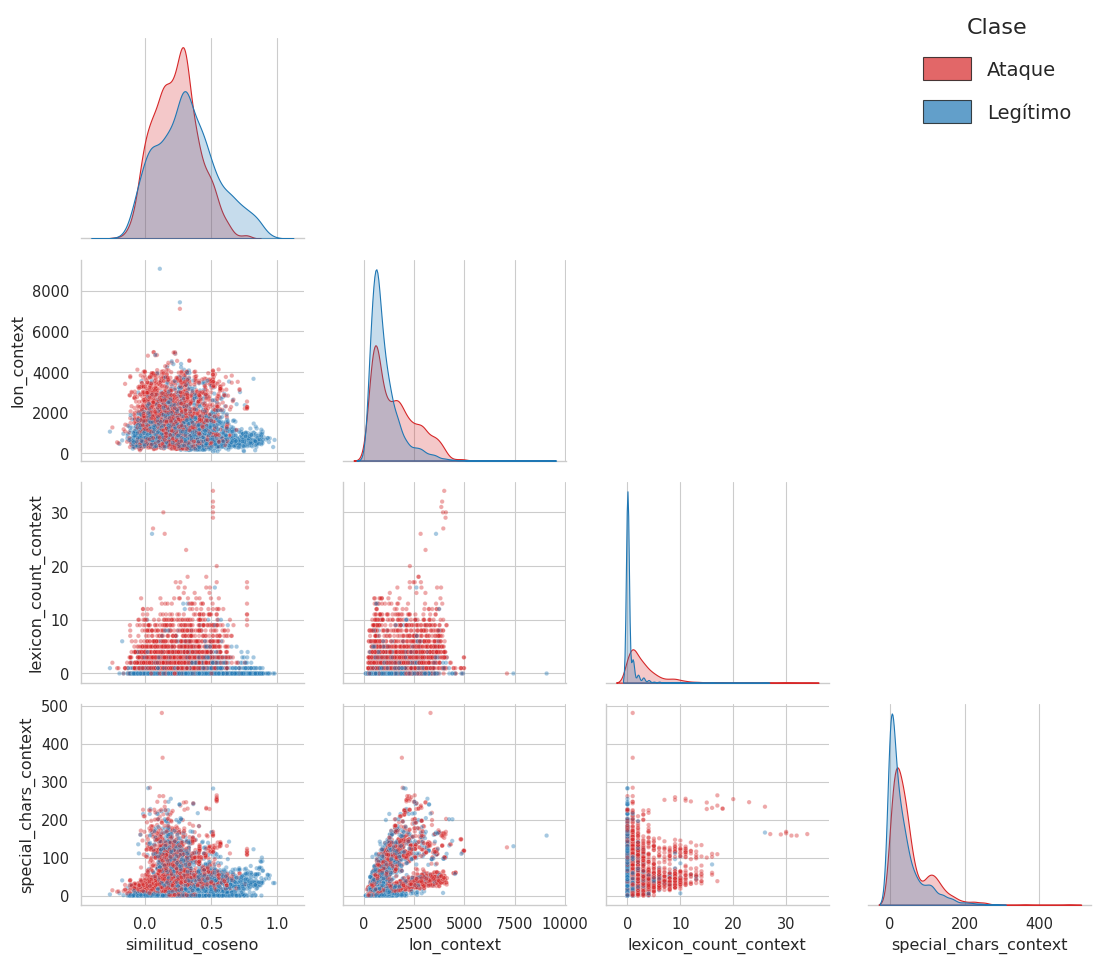

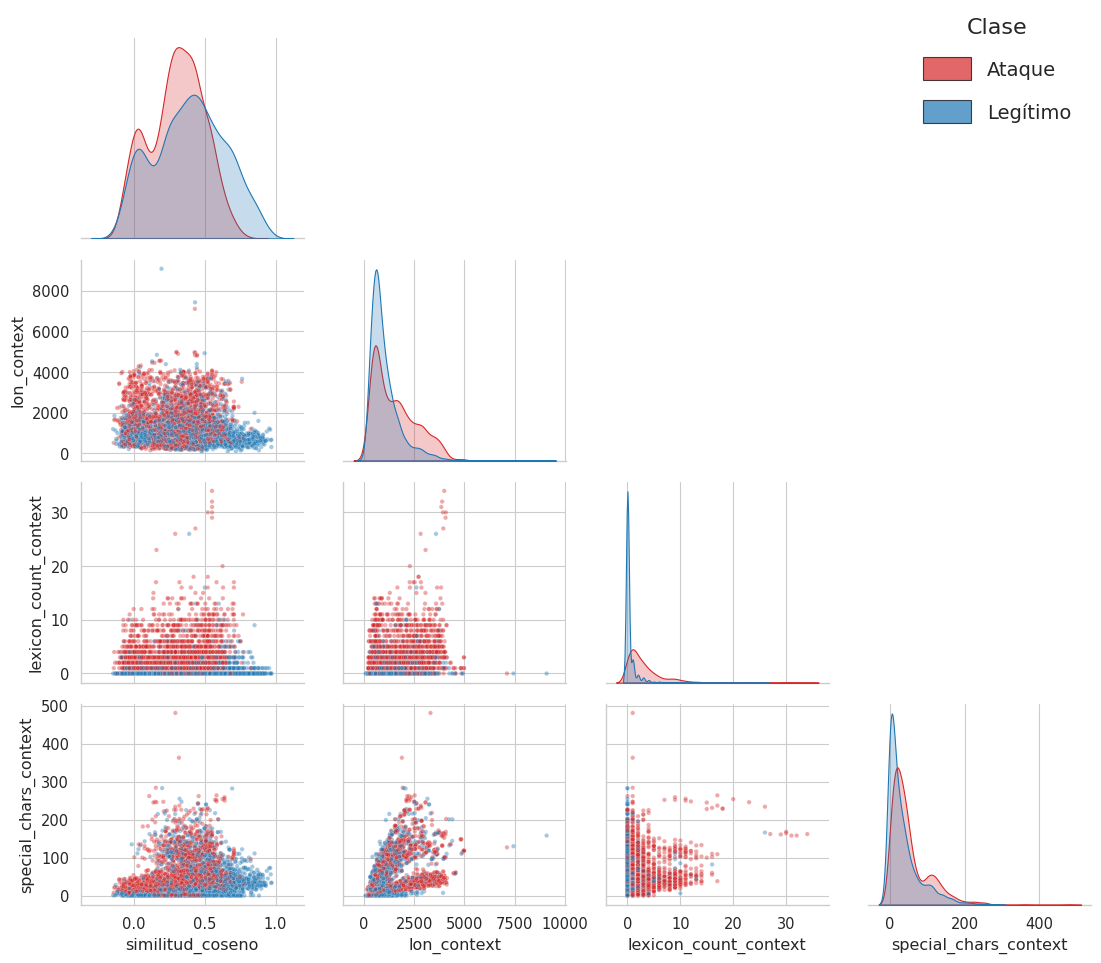

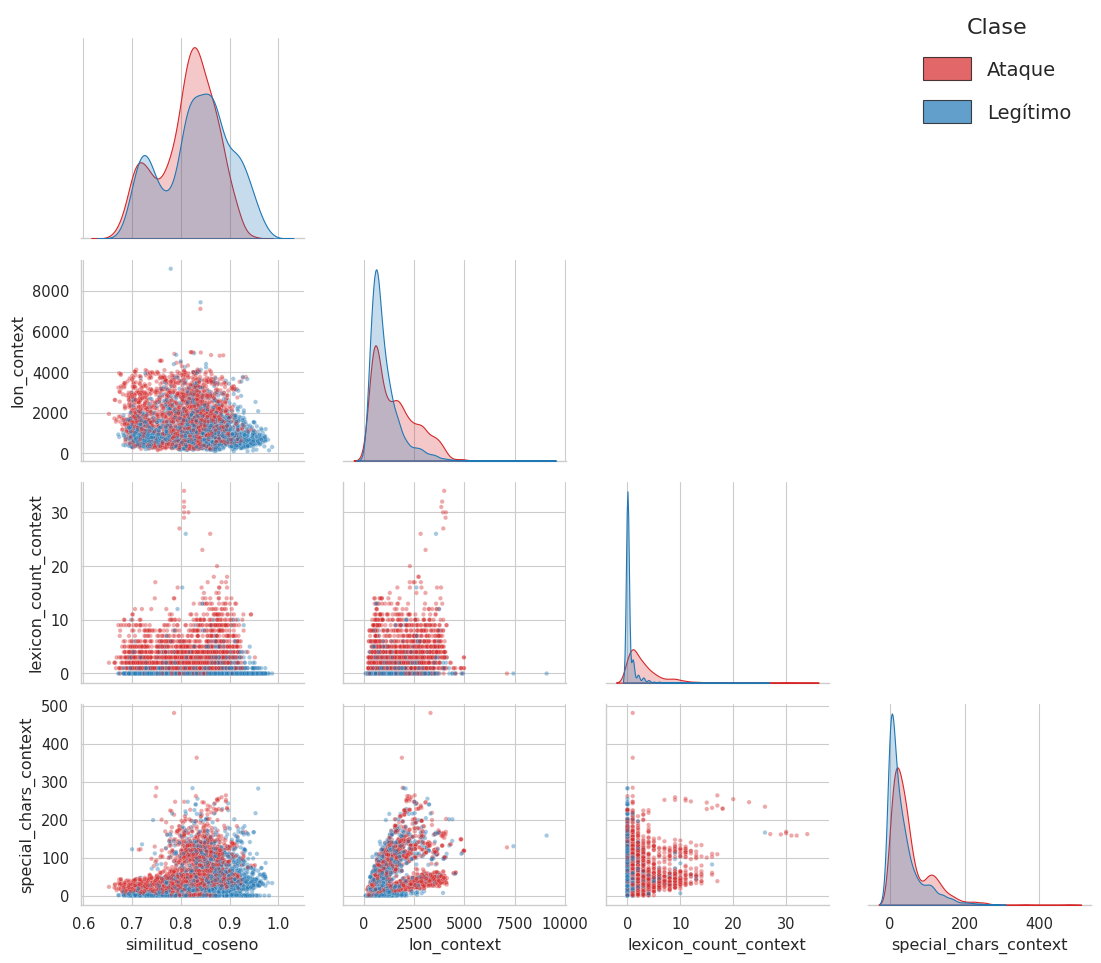

In [ ]:
for mod_emb in all_embeddings:
    generar_pairplot_embedding(mod_emb)

**Reducción de Dimensionalidad:**

In [ ]:
def visualizar_embeddings(X, y, filename, max_samples=10000):
    """Genera una figura con PCA y UMAP con posibilidad de aplicar submuestreo estratificado."""
    if len(X) > max_samples:
        X_sample, _, y_sample, _ = train_test_split(X, y, train_size=max_samples, stratify=y, random_state=SEED)
    else:
        X_sample, y_sample = X, y

    sns.set_theme(style="white", context="paper", font_scale=1.2)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    y_labels = pd.Series(y_sample).map(mapeo_labels)

    # PCA para ver estructura lineal, incluyendo la varianza explicada por componente
    pca_model = PCA(n_components=2, random_state=SEED)
    X_pca = pca_model.fit_transform(X_sample)

    var_pc1 = pca_model.explained_variance_ratio_[0] * 100
    var_pc2 = pca_model.explained_variance_ratio_[1] * 100

    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_labels, palette=colores, alpha=0.5, s=15, ax=axes[0])
    axes[0].set_title(f"PCA ({var_pc1 + var_pc2:.1f}% varianza)", fontweight='bold')
    axes[0].set_xlabel(f"PC1 ({var_pc1:.1f}% varianza)")
    axes[0].set_ylabel(f"PC2 ({var_pc2:.1f}% varianza)")

    # UMAP para ver estructura no lineal
    X_umap = umap.UMAP(n_components=2, random_state=SEED).fit_transform(X_sample)
    sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=y_labels, palette=colores, alpha=0.5, s=15, ax=axes[1])
    axes[1].set_title("UMAP", fontweight='bold')
    axes[1].set_xlabel("UMAP 1")
    axes[1].set_ylabel("UMAP 2")

    if axes[0].get_legend() is not None:
        axes[0].get_legend().remove()
    if axes[1].get_legend() is not None:
        axes[1].get_legend().remove()

    handles_custom = [
        mpatches.Patch(facecolor=color, edgecolor='black', linewidth=0.8, alpha=0.7, label=clase)
        for clase, color in colores.items()
    ]

    labels_custom = [h.get_label() for h in handles_custom]

    fig.legend(handles_custom, labels_custom, title='Clase', loc='upper center', bbox_to_anchor=(0.5, 1.05),
        ncol=2, frameon=False, fontsize=14, title_fontsize=16, handlelength=2.5, handleheight=1.5, labelspacing=1)

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.savefig(os.path.join(EDA_DIR, filename), dpi=300, bbox_inches='tight')
    plt.show()

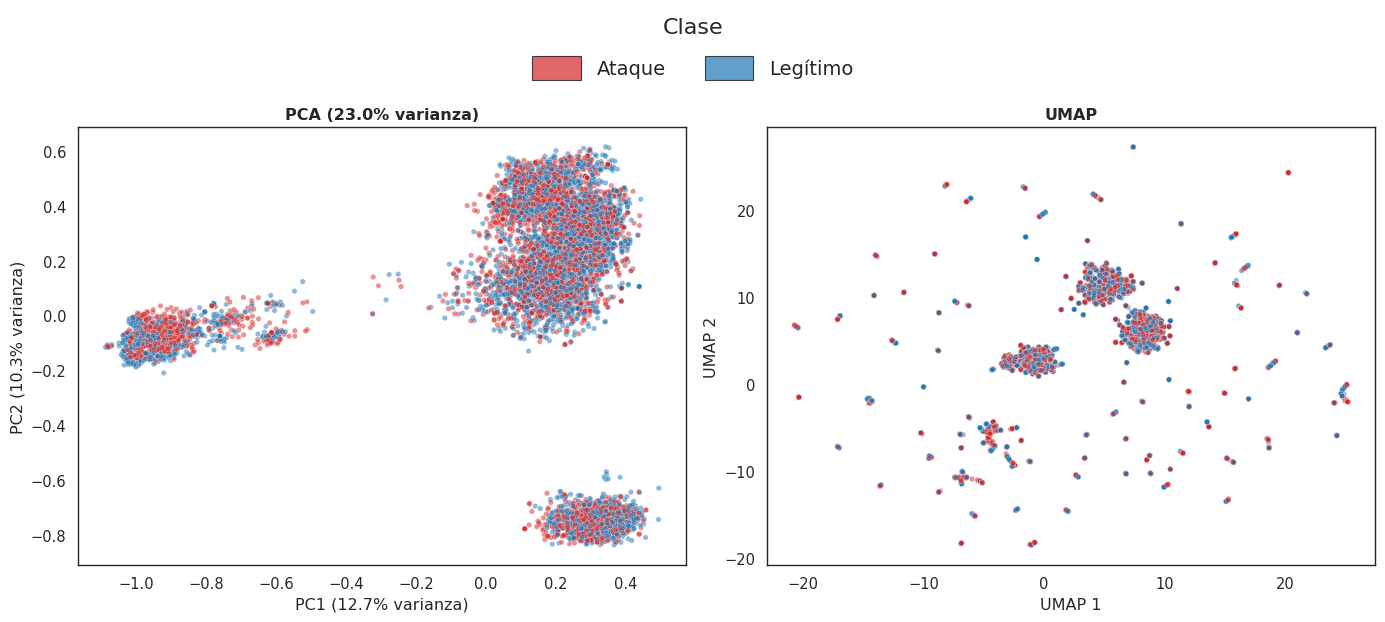

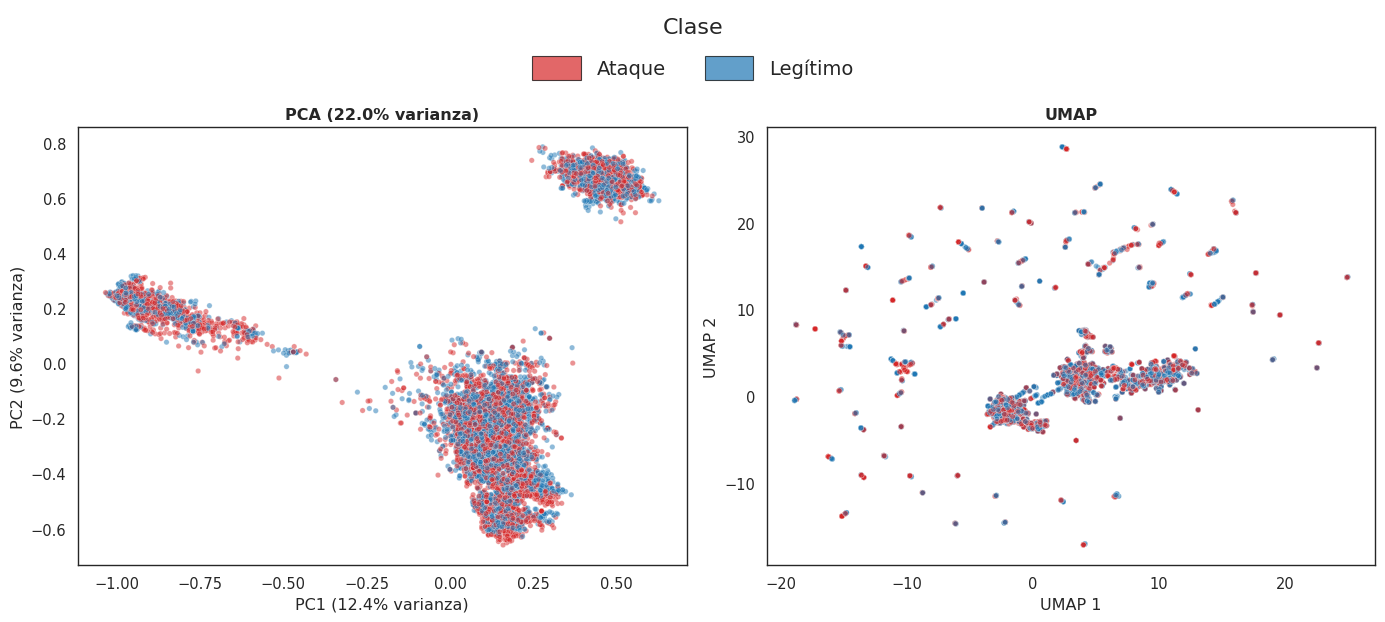

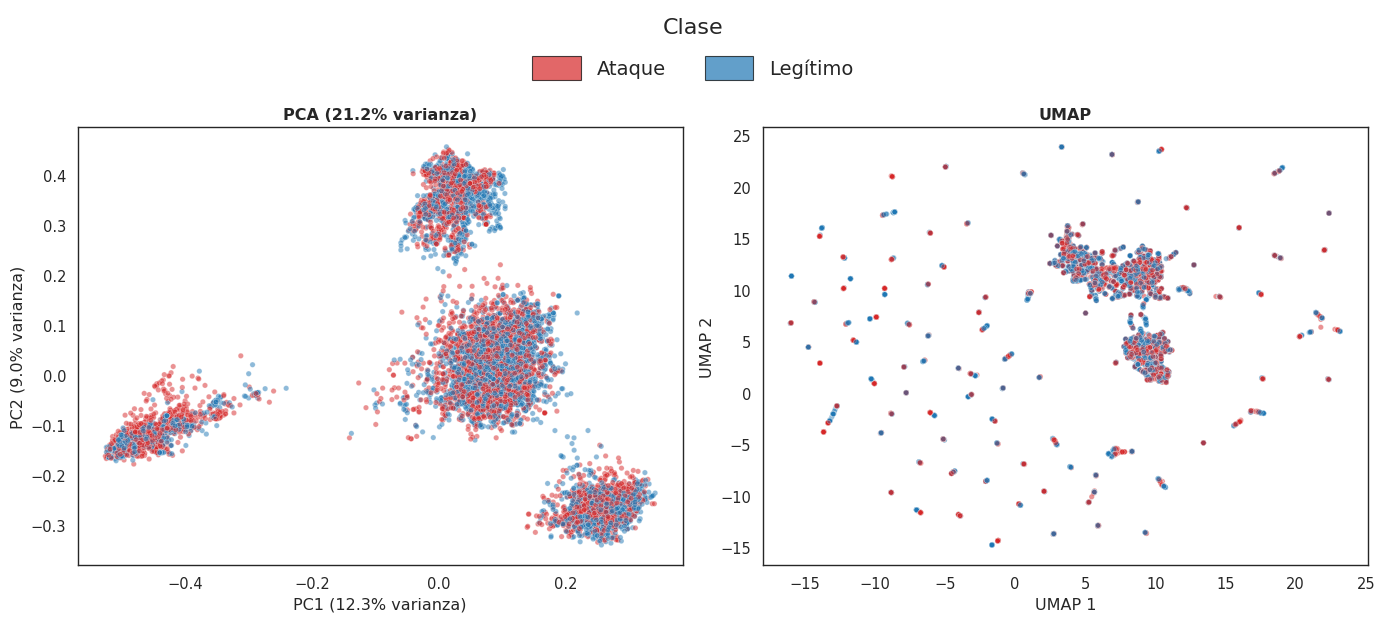

In [ ]:
# Se visualiza PCA y UMAP sobre train con embeddings fused
for key in all_embeddings:
    X_train_fused = all_embeddings[key]["fused"][idx_train]
    visualizar_embeddings(X_train_fused, y_train, filename=f"dimred_fused_{key}.png")

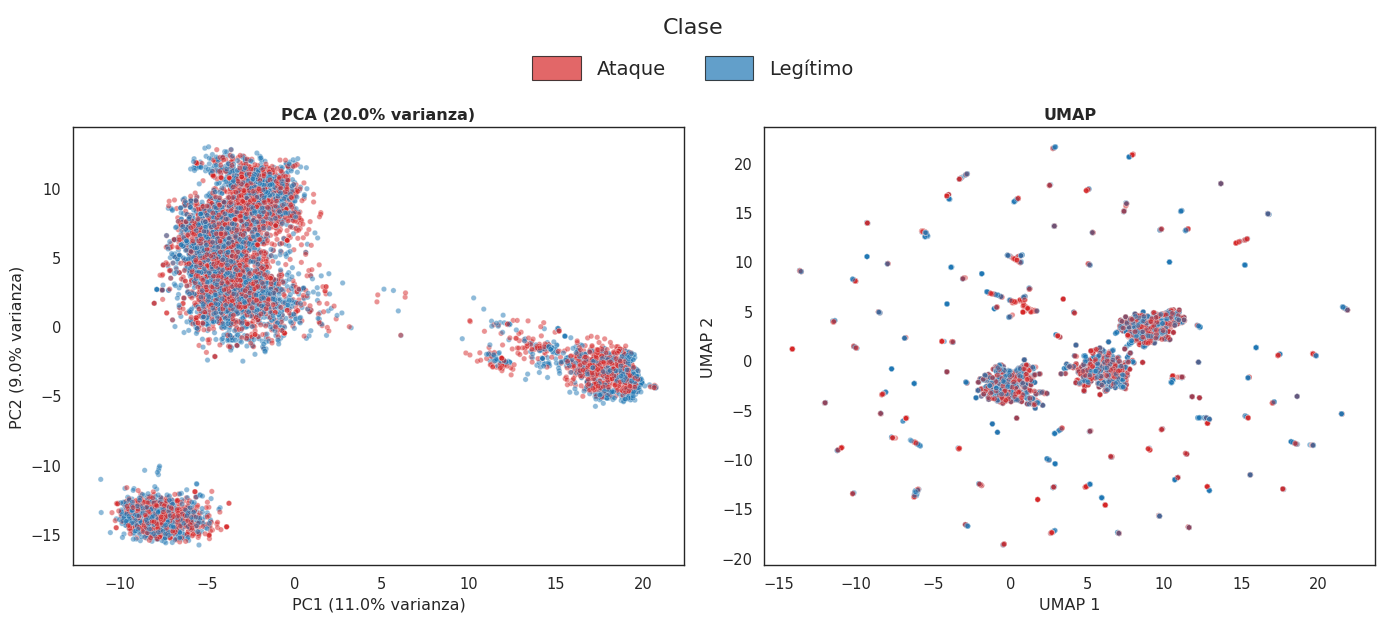

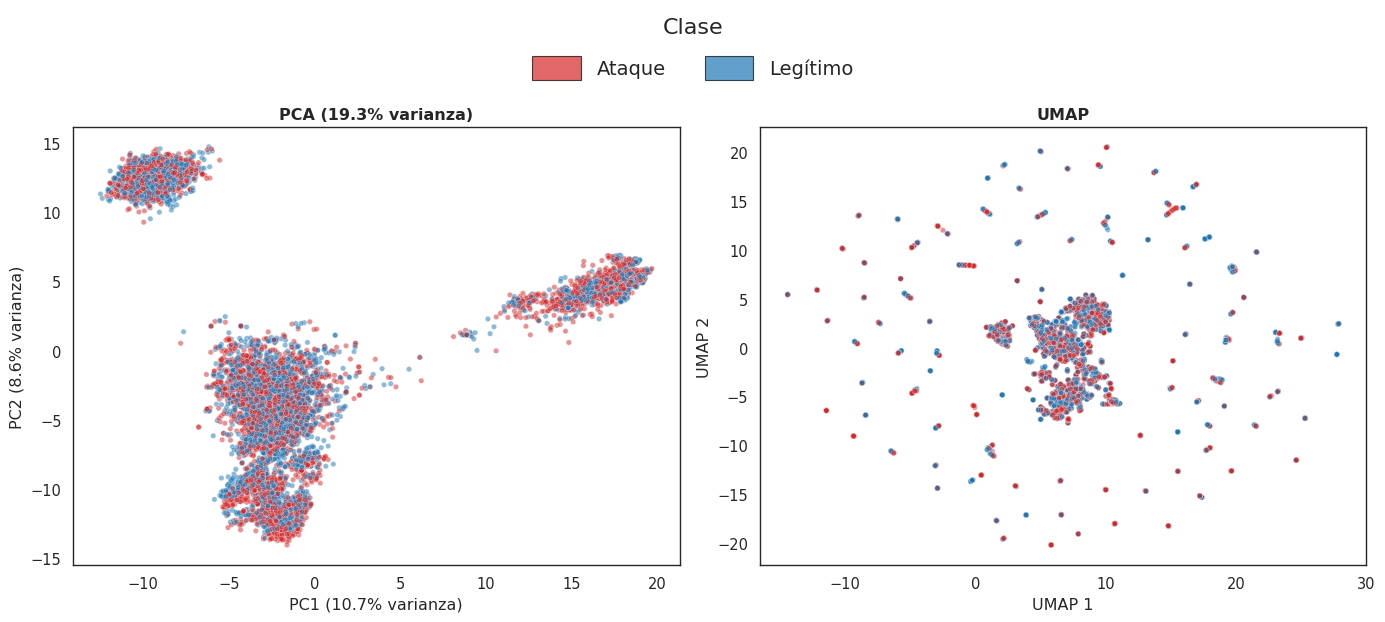

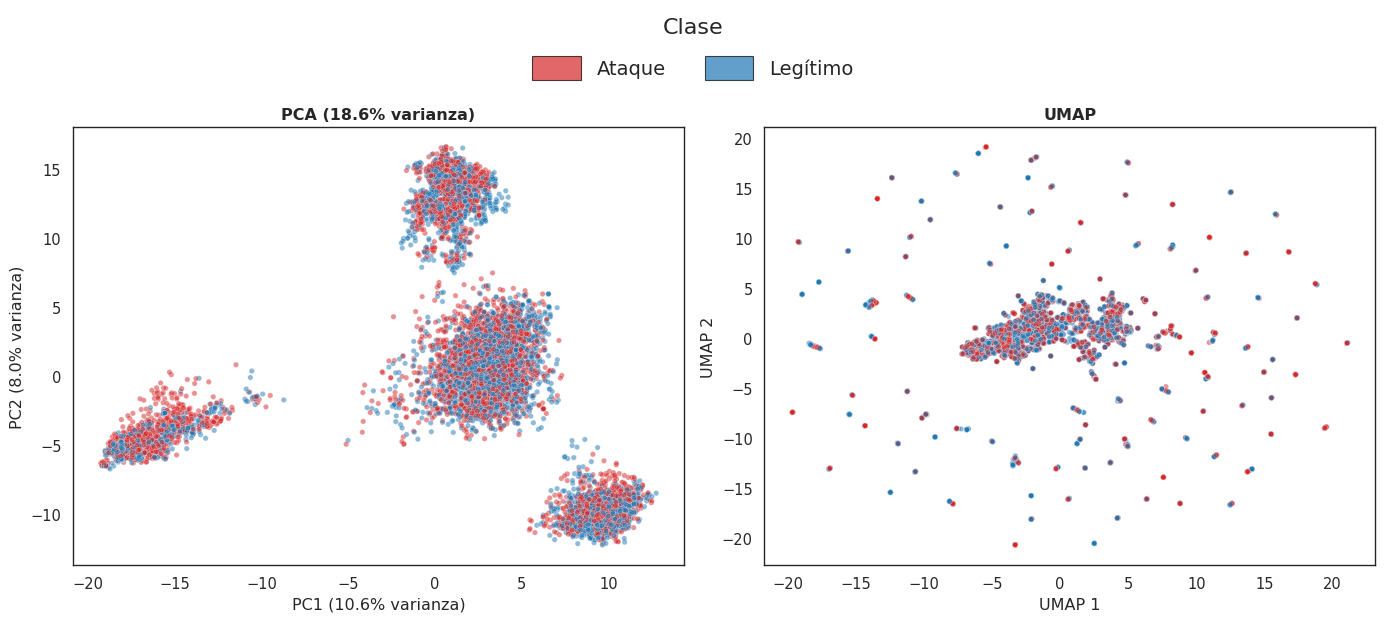

In [ ]:
# Se visualiza PCA y UMAP sobre train con embeddings fused_enriched
for key in all_embeddings:
    X_train_enriched = all_embeddings[key]["fused_enriched"][idx_train]
    scaler = StandardScaler()
    X_train_enriched_scaled = scaler.fit_transform(X_train_enriched)
    visualizar_embeddings(X_train_enriched_scaled, y_train, filename=f"dimred_enriched_{key}.png")

## **6. Entrenamiento y Evaluación de Clasificadores**

En esta sección se realiza el entrenamiento y la evaluación de los modelos de clasificación con las diferentes estrategias de extracción de embeddings y fusión de datos. En total, se plantea una evaluación de 36 configuraciones distintas a partir de la combinatoria de los siguientes elementos:

* **3 Modelos de Embeddings de 384 dimensiones:**
    * minilm-l3
    * minilm-l6
    * gte-small

* **3 Estrategias de representación de datos:**
    * Características Heurísticas (`features_rel`): Utilizando solo las características relacionales y estructurales extraídas.
    * Fusión de embeddings (`fused`): Concatenación de los embeddings de la intención del usuario y del contenido externo.
    * Fusión Enriquecida (`fused_enriched`): Concatenación de los embeddings fusionados y las características heurísticas.

* **4 Algoritmos de Clasificación:** Para poder realizar una comparativa lo más objetiva e imparcial posible, se utilizan las versiones de Random Forest, XGBoost y LightGBM inicializadas con los mismos parámetros que en el estudio de referencia de Alamsabi et al. (2026). Además, se añade la Regresión Logística como modelo lineal de referencia para evaluar escenarios extremos de Edge AI.
    * LogisticRegression
    * RandomForest
    * XGBoost
    * LightGBM

In [21]:
# Clasificadores de Alamsabi et al. (2026) + LogisticRegression básica
clasificadores = {
    "LogisticRegression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=SEED)),
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=SEED, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=SEED, n_jobs=-1, verbosity=-1)
}

# Se evaluan las tres variantes para analizar la contribucion de cada componente
variantes = ["features_rel", "fused", "fused_enriched"]

In [22]:
import tempfile

def calcular_tamano_modelo_mb(clf):
    """Calcula el tamaño del modelo entrenado en Megabytes simulando su guardado en disco."""
    with tempfile.NamedTemporaryFile(suffix='.joblib', delete=False) as f:
        joblib.dump(clf, f.name)
        size_mb = os.path.getsize(f.name) / (1024 * 1024)
    os.remove(f.name)
    return size_mb

def evaluar_clasificador(clf, X_train, y_train, X_test, y_test, nombre):
    """Entrena un clasificador y devuelve sus métricas de rendimiento sobre test."""

    # Entrenamiento
    t0_train = time.time()
    clf.fit(X_train, y_train)
    tiempo_entrenamiento = time.time() - t0_train

    # Evaluación
    t0_test = time.time()
    y_prob = clf.predict_proba(X_test)[:, 1]
    tiempo_inferencia = ((time.time() - t0_test) / len(y_test)) * 1000  # ms por muestra

    # Umbral de predicción a 0.5
    y_pred = (y_prob >= 0.5).astype(int)
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    # Cálculo de FRP
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    fpr = fp / (fp + tn)

    # Cálculo de tamaño del modelo
    tamano_mb = calcular_tamano_modelo_mb(clf)

    return {
        "clasificador": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "fpr": fpr,
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": auc(recall, precision),
        "entrenamiento_s": tiempo_entrenamiento,
        "inferencia_ms": tiempo_inferencia,
        "tamano_mb": tamano_mb,
        "y_prob": y_prob,
        "y_test": y_test
    }

In [ ]:
resultados = []

total_fits = len(all_embeddings) * len(variantes) * len(clasificadores)
contador = 0

# Resumen del entrenamiento a realizar
print("="*50)
print("Configuración de entrenamiento")
print("="*50)
print(f"Variantes de datos de entrada ({len(variantes)}): {', '.join(variantes)}")
print(f"Modelos de Embeddings ({len(all_embeddings)}): {', '.join(all_embeddings.keys())}")
print(f"Clasificadores ({len(clasificadores)}): {', '.join(clasificadores.keys())}")
print(f"Total de fits: {total_fits}")
print("="*50, "\n")

# Se entrenan y evalúan los clasificadores definidos sobre todas las
# variantes de entradas y modelos de embeddings
for emb_key in all_embeddings:
    for variante in variantes:
        X = all_embeddings[emb_key][variante]
        X_train = X[idx_train]
        X_test  = X[idx_test]

        for clf_name, clf_template in clasificadores.items():
            contador += 1
            clf = clone(clf_template)

            resultado = evaluar_clasificador(clf, X_train, y_train, X_test, y_test, clf_name)
            resultado["embedding"] = emb_key
            resultado["variante"]  = variante
            resultados.append(resultado)
            print(f"[{contador}/{total_fits}] {emb_key} | {variante} | {clf_name} -> F1: {resultado['f1_score']:.3f}  PR-AUC: {resultado['pr_auc']:.3f} T. Entren: {resultado['entrenamiento_s']:.2f}s")

Configuración de entrenamiento
Variantes de datos de entrada (3): features_rel, fused, fused_enriched
Modelos de Embeddings (3): minilm-l3, minilm-l6, gte-small
Clasificadores (4): LogisticRegression, RandomForest, XGBoost, LightGBM
Total de fits: 36

[1/36] minilm-l3 | features_rel | LogisticRegression -> F1: 0.776  PR-AUC: 0.860 T. Entren: 0.07s
[2/36] minilm-l3 | features_rel | RandomForest -> F1: 0.874  PR-AUC: 0.943 T. Entren: 7.56s
[3/36] minilm-l3 | features_rel | XGBoost -> F1: 0.892  PR-AUC: 0.956 T. Entren: 0.47s
[4/36] minilm-l3 | features_rel | LightGBM -> F1: 0.881  PR-AUC: 0.949 T. Entren: 0.43s
[5/36] minilm-l3 | fused | LogisticRegression -> F1: 0.813  PR-AUC: 0.885 T. Entren: 33.63s
[6/36] minilm-l3 | fused | RandomForest -> F1: 0.858  PR-AUC: 0.922 T. Entren: 95.97s
[7/36] minilm-l3 | fused | XGBoost -> F1: 0.878  PR-AUC: 0.954 T. Entren: 66.67s
[8/36] minilm-l3 | fused | LightGBM -> F1: 0.852  PR-AUC: 0.934 T. Entren: 49.89s
[9/36] minilm-l3 | fused_enriched | Logist

In [ ]:
res_cols = ["embedding", "variante", "clasificador", "accuracy", "f1_score", "fpr", "roc_auc", "pr_auc", "entrenamiento_s", "inferencia_ms", "tamano_mb"]
df_resultados = pd.DataFrame(resultados).sort_values("pr_auc", ascending=False).reset_index(drop=True)
display(df_resultados[res_cols].round(4))

,embedding,variante,clasificador,accuracy,f1_score,fpr,roc_auc,pr_auc,entrenamiento_s,inferencia_ms,tamano_mb
0,gte-small,fused_enriched,XGBoost,0.9554,0.9556,0.0504,0.9899,0.9880,65.0902,0.0041,0.4162
1,minilm-l6,fused_enriched,XGBoost,0.9499,0.9500,0.0536,0.9874,0.9852,61.1233,0.0040,0.4000
2,minilm-l3,fused_enriched,XGBoost,0.9464,0.9464,0.0528,0.9854,0.9842,64.9490,0.0044,0.3972
3,gte-small,fused_enriched,LightGBM,0.9337,0.9345,0.0793,0.9837,0.9819,49.3285,0.0097,0.3842
4,minilm-l6,fused_enriched,LightGBM,0.9281,0.9287,0.0801,0.9807,0.9791,56.8275,0.0098,0.3900
5,minilm-l3,fused_enriched,LightGBM,0.9291,0.9298,0.0810,0.9800,0.9790,53.8121,0.0082,0.3898
6,gte-small,fused,XGBoost,0.9163,0.9171,0.0935,0.9724,0.9667,67.1087,0.0072,0.4552
7,gte-small,fused_enriched,RandomForest,0.9056,0.9076,0.1167,0.9658,0.9596,90.6174,0.0166,8.4566
8,minilm-l3,fused_enriched,RandomForest,0.9049,0.9068,0.1162,0.9624,0.9573,103.8271,0.0168,7.6938
9,minilm-l6,features_rel,XGBoost,0.8892,0.8896,0.1142,0.9606,0.9563,0.4160,0.0021,0.3187


In [ ]:
# Se guardan los resultados completos y solo con las métricas en Drive
dict_path = os.path.join(RESULTS_DIR, "resultados.joblib")
joblib.dump(resultados, dict_path)

csv_path = os.path.join(RESULTS_DIR, "resultados.csv")
df_resultados[res_cols].to_csv(csv_path, index=False)

print(f"Resultados guardados en: {RESULTS_DIR}")

Resultados guardados en: /content/drive/MyDrive/TFM/results


## **7. Visualización y Análisis de Resultados**

En esta sección se cargan y analizan los resultados obtenidos durante la fase de experimentación. En primer lugar, se evalúa el rendimiento del mejor modelo clasificador (XGBoost con embeddings GTE-small y fusión enriquecida) en diferentes puntos de corte, determinando el umbral necesario para cumplir con el criterio operativo establecido de mantener una Tasa de Falsos Positivos (FPR) máxima del 5%.

A continuación, se definen y ejecutan las funciones de visualización para generar las gráficas comparativas del estudio:

* **Comparativa general de métricas:** Gráficos de barras evaluando Exactitud, F1-Score, ROC-AUC y PR-AUC por modelo de embedding y clasificador.

* **Curvas de Rendimiento:** Curvas ROC y Precision-Recall evaluando la robustez de los modelos frente a los distintos umbrales de decisión.

* **Estudios de Ablación:** 1. Análisis del impacto individual de cada estrategia de representación de datos (solo semántica, solo heurística o fusión enriquecida) en el rendimiento. 2. Análisis de rendimiento en un escenario Edge AI extremo prescindiendo de los modelos de embeddings (características heurísticas puras, excluyendo la similitud coseno, frente al conjunto de características completo).

* **Compromiso en Edge AI:** Gráfico de dispersión para evaluar la viabilidad técnica comparando el rendimiento, la latencia de inferencia por muestra y el tamaño en disco de cada configuración.

#### **Carga y visualización de resultados (tablas):**

In [23]:
# Cargar resultados de entrenamientos anteriores si existen
if os.path.exists(RESULTS_DIR):
    resultados = joblib.load(os.path.join(RESULTS_DIR, "resultados.joblib"))
    df_resultados = pd.DataFrame(resultados).sort_values("pr_auc", ascending=False).reset_index(drop=True)
    print(f"Resultados cargados.")

Resultados cargados.


In [24]:
# Visualizar tabla de resultados completos
df_resultados_wd = df_resultados.copy()
df_resultados_wd['configuracion'] = df_resultados_wd['embedding'] + ' | ' + df_resultados_wd['variante'] + ' | ' + df_resultados_wd['clasificador']

res_cols = ["configuracion", "accuracy", "f1_score", "fpr", "roc_auc", "pr_auc", "inferencia_ms", "tamano_mb"]
display(df_resultados_wd[res_cols].sort_values("pr_auc", ascending=False).round(4))

,configuracion,accuracy,f1_score,fpr,roc_auc,pr_auc,inferencia_ms,tamano_mb
0,gte-small | fused_enriched | XGBoost,0.9554,0.9556,0.0504,0.9899,0.9880,0.0041,0.4162
1,minilm-l6 | fused_enriched | XGBoost,0.9499,0.9500,0.0536,0.9874,0.9852,0.0040,0.4000
2,minilm-l3 | fused_enriched | XGBoost,0.9464,0.9464,0.0528,0.9854,0.9842,0.0044,0.3972
3,gte-small | fused_enriched | LightGBM,0.9337,0.9345,0.0793,0.9837,0.9819,0.0097,0.3842
4,minilm-l6 | fused_enriched | LightGBM,0.9281,0.9287,0.0801,0.9807,0.9791,0.0098,0.3900
5,minilm-l3 | fused_enriched | LightGBM,0.9291,0.9298,0.0810,0.9800,0.9790,0.0082,0.3898
6,gte-small | fused | XGBoost,0.9163,0.9171,0.0935,0.9724,0.9667,0.0072,0.4552
7,gte-small | fused_enriched | RandomForest,0.9056,0.9076,0.1167,0.9658,0.9596,0.0166,8.4566
8,minilm-l3 | fused_enriched | RandomForest,0.9049,0.9068,0.1162,0.9624,0.9573,0.0168,7.6938
9,minilm-l6 | features_rel | XGBoost,0.8892,0.8896,0.1142,0.9606,0.9563,0.0021,0.3187


In [ ]:
# Top 10 resultados por PR-AUC
res_cols = ["embedding", "variante", "clasificador", "accuracy", "f1_score", "roc_auc", "pr_auc", "inferencia_ms", "tamano_mb"]
display(df_resultados[res_cols].head(10).round(4))

,embedding,variante,clasificador,accuracy,f1_score,roc_auc,pr_auc,inferencia_ms,tamano_mb
0,gte-small,fused_enriched,XGBoost,0.9554,0.9556,0.9899,0.9880,0.0041,0.4162
1,minilm-l6,fused_enriched,XGBoost,0.9499,0.9500,0.9874,0.9852,0.0040,0.4000
2,minilm-l3,fused_enriched,XGBoost,0.9464,0.9464,0.9854,0.9842,0.0044,0.3972
3,gte-small,fused_enriched,LightGBM,0.9337,0.9345,0.9837,0.9819,0.0097,0.3842
4,minilm-l6,fused_enriched,LightGBM,0.9281,0.9287,0.9807,0.9791,0.0098,0.3900
5,minilm-l3,fused_enriched,LightGBM,0.9291,0.9298,0.9800,0.9790,0.0082,0.3898
6,gte-small,fused,XGBoost,0.9163,0.9171,0.9724,0.9667,0.0072,0.4552
7,gte-small,fused_enriched,RandomForest,0.9056,0.9076,0.9658,0.9596,0.0166,8.4566
8,minilm-l3,fused_enriched,RandomForest,0.9049,0.9068,0.9624,0.9573,0.0168,7.6938
9,minilm-l6,features_rel,XGBoost,0.8892,0.8896,0.9606,0.9563,0.0021,0.3187


**Evaluación de resultados con distintos FPR para un modelo específico**

In [ ]:
# Seleccionar el modelo
modelo = next((r for r in resultados
                   if r['embedding'] == 'gte-small'
                   and r['variante'] == 'fused_enriched'
                   and r['clasificador'] == 'XGBoost'), None)

if modelo is not None:
    y_test = modelo['y_test']
    y_prob = modelo['y_prob']

    # Calcular la curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    fpr_objetivos = [0.05, 0.03, 0.02, 0.01]

    print("Configuración: gte-small | fused_enriched | XGBoost")
    print("=" * 60)

    for fpr_obj in fpr_objetivos:
        # Encontrar el índice del umbral óptimo
        indice_optimo = np.where(fpr <= fpr_obj)[0][-1]
        umbral_necesario = thresholds[indice_optimo]

        # Aplicar el umbral para obtener predicciones binarias (0 o 1)
        y_pred_custom = (y_prob >= umbral_necesario).astype(int)

        # Calcular métricas dependientes del umbral
        precision = precision_score(y_test, y_pred_custom, zero_division=0)
        f1 = f1_score(y_test, y_pred_custom)
        accuracy = accuracy_score(y_test, y_pred_custom)

        # Extraer matriz de confusión para ver el detalle de Falsos Positivos/Negativos
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_custom).ravel()
        fpr_real = fp / (fp + tn) # Equivalente a fpr[indice_optimo]
        especificidad = tn / (tn + fp)

        print(f"Objetivo Máximo FPR: {fpr_obj*100}%")
        print("-" * 30)
        print(f"  -> Umbral requerido: {umbral_necesario:.4f}")
        print(f"  -> FPR Real:         {fpr_real*100:.2f}% (Especificidad: {especificidad*100:.2f}%)")
        print(f"  -> Sensibilidad:     {tpr[indice_optimo]:.4f}")
        print(f"  -> Precisión:        {precision:.4f}")
        print(f"  -> F1-Score:         {f1:.4f}")
        print(f"  -> Exactitud:        {accuracy:.4f}")
        print(f"  -> Detalle:          {tp} TP | {fn} FN | {fp} FP | {tn} TN\n")
else:
    print("No se encontró esa configuración en la lista de resultados.")

Configuración: gte-small | fused_enriched | XGBoost
Objetivo Máximo FPR: 5.0%
------------------------------
  -> Umbral requerido: 0.5070
  -> FPR Real:         5.00% (Especificidad: 95.00%)
  -> Sensibilidad:     0.9604
  -> Precisión:        0.9505
  -> F1-Score:         0.9554
  -> Exactitud:        0.9552
  -> Detalle:          6627 TP | 273 FN | 345 FP | 6555 TN

Objetivo Máximo FPR: 3.0%
------------------------------
  -> Umbral requerido: 0.7368
  -> FPR Real:         3.00% (Especificidad: 97.00%)
  -> Sensibilidad:     0.9188
  -> Precisión:        0.9684
  -> F1-Score:         0.9430
  -> Exactitud:        0.9444
  -> Detalle:          6340 TP | 560 FN | 207 FP | 6693 TN

Objetivo Máximo FPR: 2.0%
------------------------------
  -> Umbral requerido: 0.8589
  -> FPR Real:         2.00% (Especificidad: 98.00%)
  -> Sensibilidad:     0.8657
  -> Precisión:        0.9774
  -> F1-Score:         0.9181
  -> Exactitud:        0.9228
  -> Detalle:          5973 TP | 927 FN | 138 FP

#### **Definición de funciones de visualización:**

In [48]:
# Diccionario de colores extraídos de la paleta 'deep' de seaborn
# para mantenera la consistencia de colores entre gráficos

COLORES_MODELOS = {
    'XGBoost': '#5975a4',
    'LightGBM': '#cc8963',
    'RandomForest': '#5f9e6e',
    'LogisticRegression': '#b55d60'
}

In [56]:
def plot_barras_metricas(df_resultados, variante="fused_enriched"):
    """
    Genera gráficas de barras para comparar distintos clasificadores y embeddings.
    Permite filtrar por una de las variantes.
    """
    df_plot = df_resultados[df_resultados['variante'] == variante]

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    metricas = [
        ('accuracy', 'Comparativa de Exactitud', axes[0, 0]),
        ('f1_score', 'Comparativa de F1-Score', axes[0, 1]),
        ('roc_auc', 'Comparativa de ROC-AUC', axes[1, 0]),
        ('pr_auc', 'Comparativa de PR-AUC', axes[1, 1])
    ]

    for columna, titulo, ax in metricas:
        sns.barplot(data=df_plot, x='embedding', y=columna, hue='clasificador',
                    palette=COLORES_MODELOS, ax=ax, edgecolor='black', linewidth=0.5)

        ax.set_title(titulo, fontweight='bold', fontsize=12)
        ax.set_xlabel("Modelo de Embeddings")

        nombres_metricas = {'accuracy': 'Exactitud', 'f1_score': 'F1-Score', 'roc_auc': 'ROC-AUC', 'pr_auc': 'PR-AUC'}
        ax.set_ylabel(nombres_metricas[columna])

        # Se calcula dinamicamente el eje Y para ver mejor las diferencias
        # y_min = max(0.0, df_plot[columna].min() - 0.05)
        ax.set_ylim(0.75, 1.0)

        if ax.get_legend() is not None:
            ax.get_legend().remove()

    handles, labels = ax.get_legend_handles_labels()

    # Leyenda centrada arriba y horizontal
    fig.legend(handles, labels, title='Clasificador', loc='upper center', bbox_to_anchor=(0.5, 1.05),
               ncol=4, frameon=False, fontsize=14, title_fontsize=16, handlelength=2.5, handleheight=1.5, labelspacing=1)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(os.path.join(RES_GRAPH_DIR, f"comparativa_metricas_{variante}.png"), dpi=300, bbox_inches='tight')
    plt.show()

In [30]:
def plot_curvas_roc_pr(resultados_lista, modelo_embedding="gte-small", variante="fused_enriched"):
    """
    Genera las curvas ROC y PR para un embedding específico comparando todos los clasificadores.
    """
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    datos_plot = [r for r in resultados_lista if r['embedding'] == modelo_embedding and r['variante'] == variante]

    for modelo in datos_plot:
        nombre = modelo['clasificador']
        y_test = modelo['y_test']
        y_prob = modelo['y_prob']
        color = COLORES_MODELOS[nombre]

        # Curva ROC
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_roc = modelo['roc_auc']
        axes[0].plot(fpr, tpr, label=f"{nombre} (AUC = {auc_roc:.3f})", color=color, linewidth=2)

        # Curva PR
        precision, recall, _ = precision_recall_curve(y_test, y_prob)
        auc_pr = modelo['pr_auc']
        axes[1].plot(recall, precision, label=f"{nombre} (AUC = {auc_pr:.3f})", color=color, linewidth=2)

    # Formato de gráfica ROC
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Línea Base (AUC = 0.500)')
    axes[0].set_title(f"Curvas ROC - {modelo_embedding}", fontweight='bold', fontsize=14)
    axes[0].set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=13, labelpad=10)
    axes[0].set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=13, labelpad=10)
    axes[0].axvline(x=0.05, color='red', linestyle=':', linewidth=2, label='Límite Operativo (FPR = 5%)')
    axes[0].legend(loc="best", fontsize=11)
    axes[0].set_xlim([-0.02, 1.02])
    axes[0].set_ylim([-0.02, 1.02])

    # Formato de gráfica PR
    axes[1].axhline(y=0.5, color='k', linestyle='--', alpha=0.5, label='Línea Base (AUC = 0.500)')
    axes[1].set_title(f"Curvas Precision-Recall - {modelo_embedding}", fontweight='bold', fontsize=14)
    axes[1].set_xlabel("Recall", fontsize=13, labelpad=10)
    axes[1].set_ylabel("Precisión", fontsize=13, labelpad=10)
    axes[1].legend(loc="best", fontsize=11)
    axes[1].set_xlim([-0.02, 1.02])
    axes[1].set_ylim([0.48, 1.02])

    plt.tight_layout()
    plt.savefig(os.path.join(RES_GRAPH_DIR, f"curvas_roc_pr_{modelo_embedding}.png"), dpi=300, bbox_inches='tight')
    plt.show()

In [31]:
def plot_tradeoff_edge_ai(df_resultados, variante="fused_enriched"):
    """
    Genera un gráfico de dispersión para evaluar el compromiso entre el rendimiento (pr-auc) y el tiempo de inferencia.
    El tamaño de los puntos representa el tamaño del modelo en memoria en MB.
    """
    df_plot = df_resultados[df_resultados['variante'] == variante].copy()

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

    fig = plt.figure(figsize=(12, 6))

    ax = sns.scatterplot(data=df_plot, x='inferencia_ms', y='pr_auc', hue='clasificador', palette=COLORES_MODELOS,
                         size='tamano_mb', sizes=(100, 1000), alpha=0.8, edgecolor='black', linewidth=1)

    y_min = df_plot['pr_auc'].min() - 0.01
    plt.ylim(max(0, y_min), 1.0)

    plt.xlabel("Tiempo de Inferencia (ms por muestra)")
    plt.ylabel("Rendimiento (PR-AUC)")

    # Anotaciones de los puntos
    textos = []
    for i in range(df_plot.shape[0]):
        textos.append(plt.text(df_plot['inferencia_ms'].iloc[i],
                               df_plot['pr_auc'].iloc[i],
                               df_plot['embedding'].iloc[i],
                               fontsize=10, color='black'))

    # Empuja los textos para que no se toquen entre sí ni con los puntos
    adjust_text(textos, arrowprops=dict(arrowstyle='-', color='black'))

    handles, labels = ax.get_legend_handles_labels()

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    handles_custom = [
        mpatches.Patch(facecolor=COLORES_MODELOS[clf], edgecolor='black', linewidth=0.8, label=clf)
        for clf in COLORES_MODELOS.keys()
        if clf in df_plot['clasificador'].values
    ]

    # Leyenda centrada arriba y horizontal
    fig.legend(handles=handles_custom, title="Clasificador", loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4, frameon=False,
        fontsize=14, title_fontsize=16, handlelength=1.5, handleheight=1.0, labelspacing=1)

    plt.tight_layout(rect=[0, 0, 1, 0.9])

    plt.savefig(os.path.join(RES_GRAPH_DIR, f"rend_efic_{variante}.png"), dpi=300, bbox_inches='tight')
    plt.show()

In [34]:
def plot_estudio_ablacion(df_resultados, embeddings=["gte-small", "minilm-l6", "minilm-l3"], metrica="pr_auc"):
    """
    Genera una gráfica con subplots para el Estudio de Ablación,
    comparando las tres estrategias de datos para varios embeddings simultáneamente.
    """
    df_ablation = df_resultados[df_resultados['embedding'].isin(embeddings)].copy()

    orden_variantes = ["fused_enriched", "fused", "features_rel"]

    nombres_variantes = {
        "fused_enriched": "Embeddings + Características",
        "fused": "Solo Embeddings",
        "features_rel": "Solo Características"
    }

    nombres_clasificadores = {
        "XGBoost": "XGBoost",
        "LightGBM": "LightGBM",
        "RandomForest": "RandomForest",
        "LogisticRegression": "L. Regression"
    }

    df_ablation['Variante_Nombre'] = df_ablation['variante'].map(nombres_variantes)
    df_ablation['Clf_Corto'] = df_ablation['clasificador'].map(lambda x: nombres_clasificadores.get(x, x))

    orden_variantes_nombres = [nombres_variantes[v] for v in orden_variantes]

    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
    colores = ["#5975a4", "#cc8963", "#5f9e6e"]

    fig, axes = plt.subplots(1, len(embeddings), figsize=(16, 6), sharey=True)
    nombres_ejes = {'accuracy': 'Exactitud', 'f1_score': 'F1-Score', 'roc_auc': 'ROC-AUC', 'pr_auc': 'PR-AUC'}
    nombre_metrica = nombres_ejes.get(metrica, metrica.upper())

    y_min = df_ablation[metrica].min() - 0.05

    for i, embedding in enumerate(embeddings):
        ax = axes[i]
        df_subset = df_ablation[df_ablation['embedding'] == embedding]

        sns.barplot(data=df_subset, x='Clf_Corto', y=metrica, hue='Variante_Nombre',
                    hue_order=orden_variantes_nombres, palette=colores,
                    edgecolor='black', linewidth=0.8, ax=ax)

        ax.set_title(f"{embedding}", fontweight='bold', pad=10, fontsize=14)
        ax.set_xlabel("Clasificador", fontsize=13, labelpad=10)

        if i == 0:
            ax.set_ylabel(f"Rendimiento ({nombre_metrica})", fontsize=13, labelpad=10)
        else:
            ax.set_ylabel("")

        ax.set_ylim(max(0, y_min), 1.01)

        if ax.get_legend() is not None:
            ax.get_legend().remove()

        # for p in ax.patches:
        #     altura = p.get_height()
        #     if pd.notnull(altura) and altura > 0:
        #         ax.annotate(f"{altura:.3f}", (p.get_x() + p.get_width() / 2., altura),
        #                     ha='center', va='bottom', fontsize=11, color='black',
        #                     rotation=90, xytext=(0, 4), textcoords='offset points')

    handles, labels = axes[0].get_legend_handles_labels()

    # Leyenda centrada arriba y horizontal
    fig.legend(handles, labels, title="Estrategia de Representación", loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=False,
               fontsize=13, title_fontsize=14, handlelength=2.5, handleheight=1.5, labelspacing=1)

    plt.tight_layout(rect=[0, 0, 1, 0.9])
    plt.savefig(os.path.join(RES_GRAPH_DIR, f"estudio_ablacion_{metrica}.png"), dpi=300, bbox_inches='tight')
    plt.show()

#### **Visualización y Guardado de Resultados en Drive:**

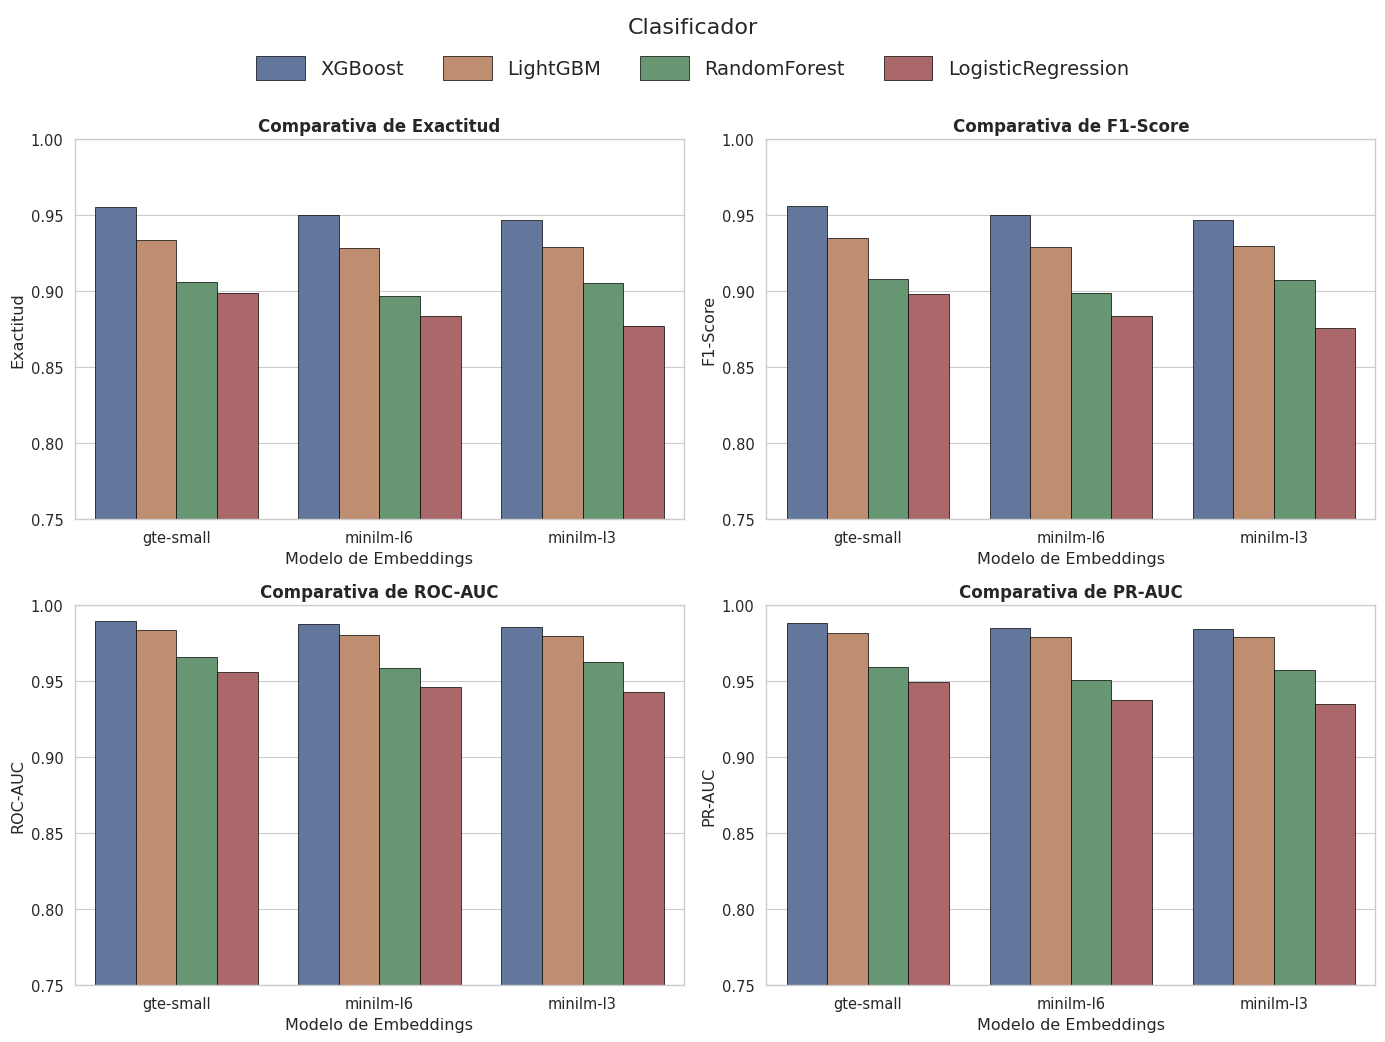

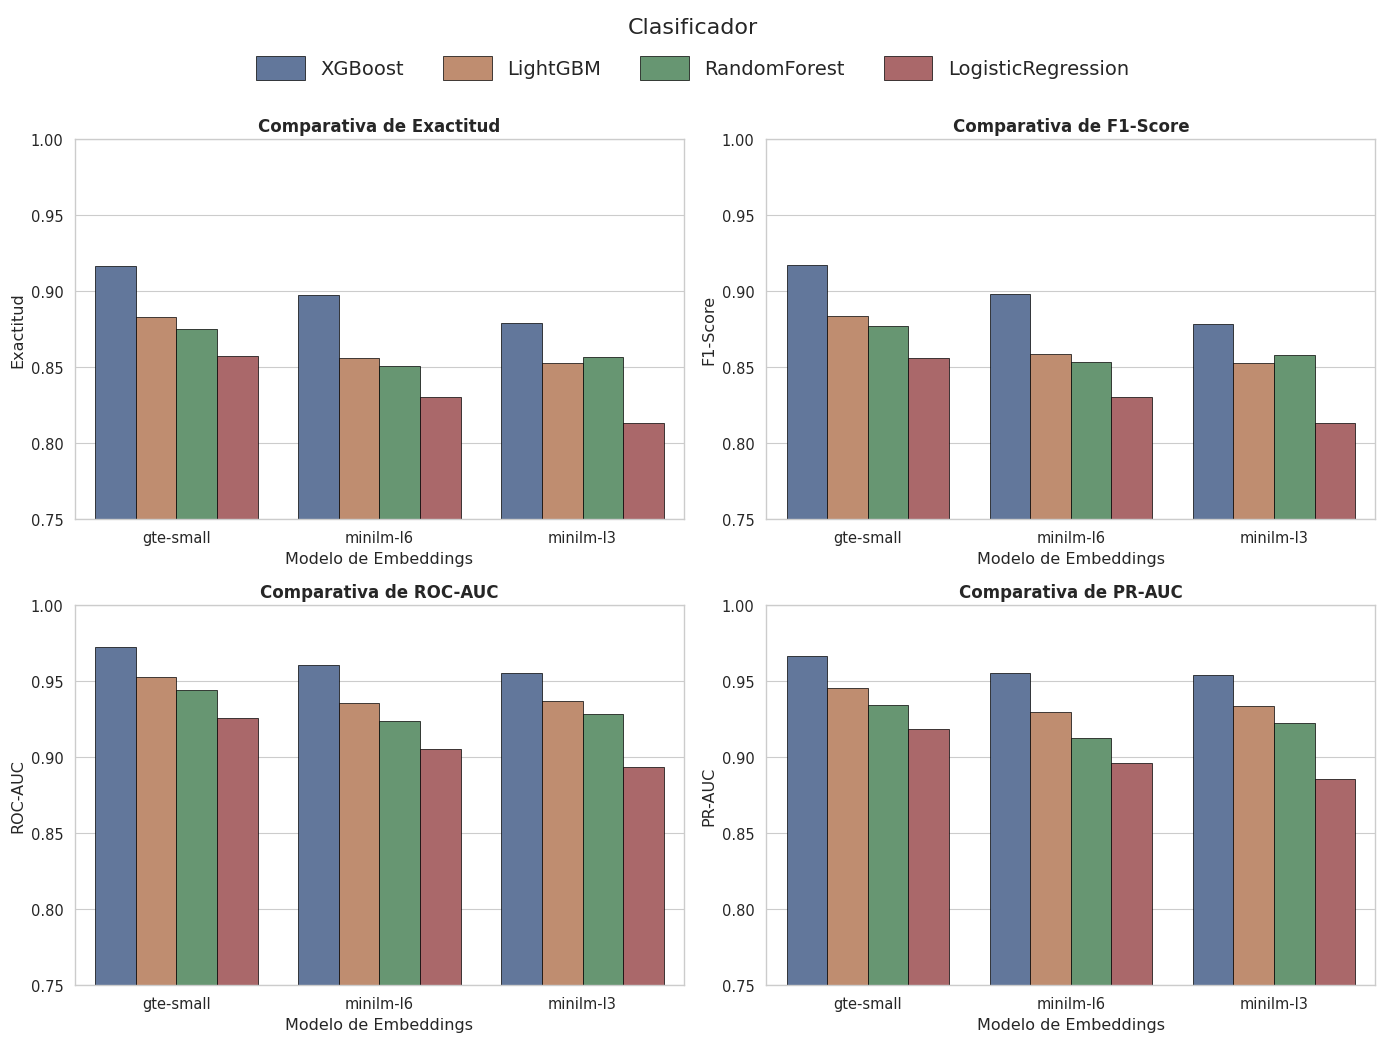

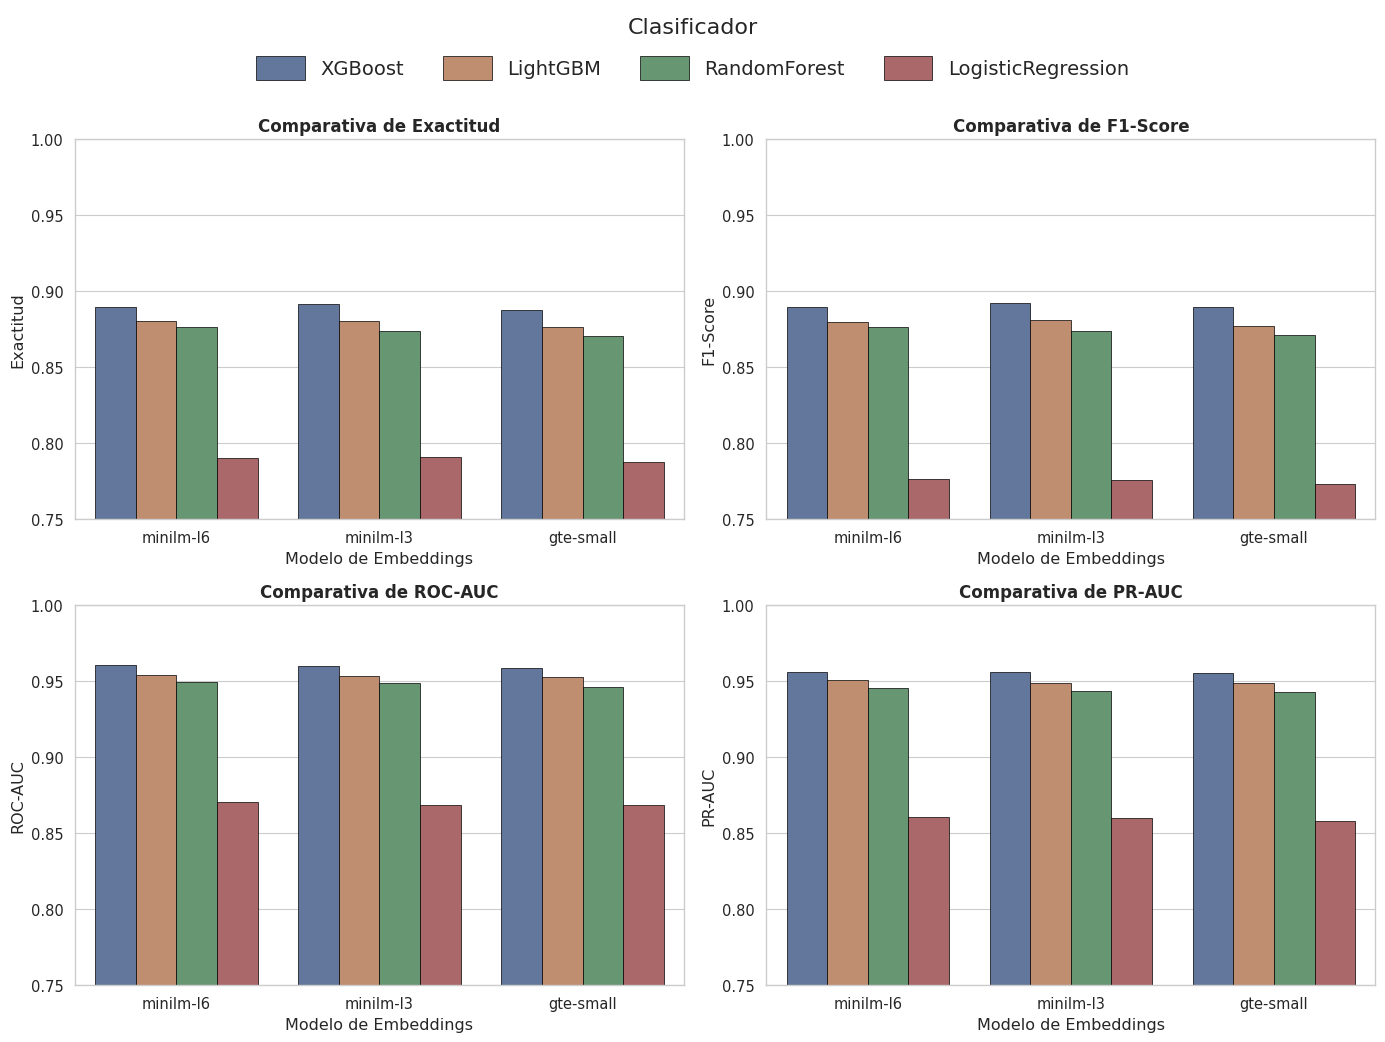

In [57]:
plot_barras_metricas(df_resultados, variante="fused_enriched")
plot_barras_metricas(df_resultados, variante="fused")
plot_barras_metricas(df_resultados, variante="features_rel")

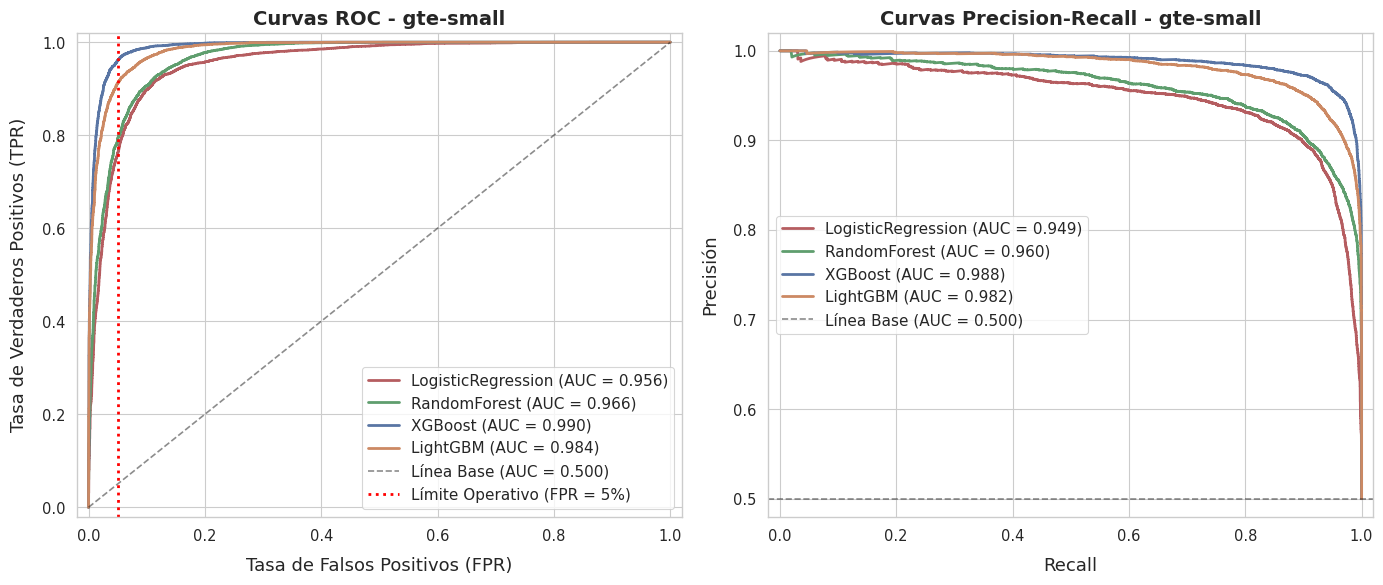

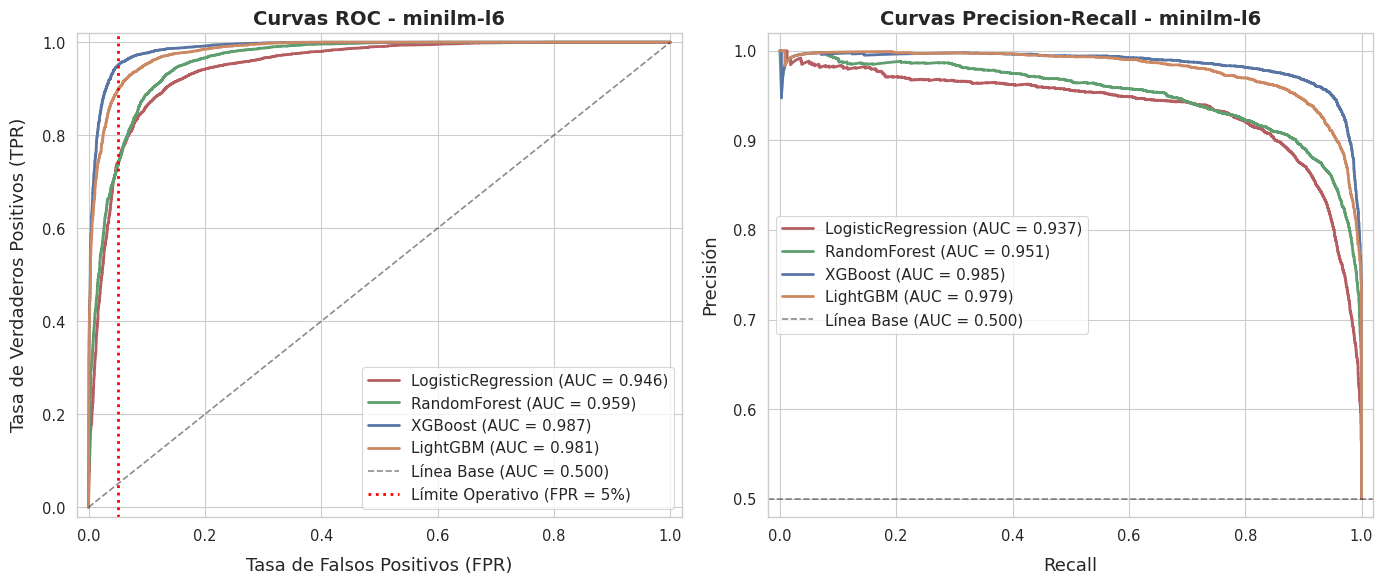

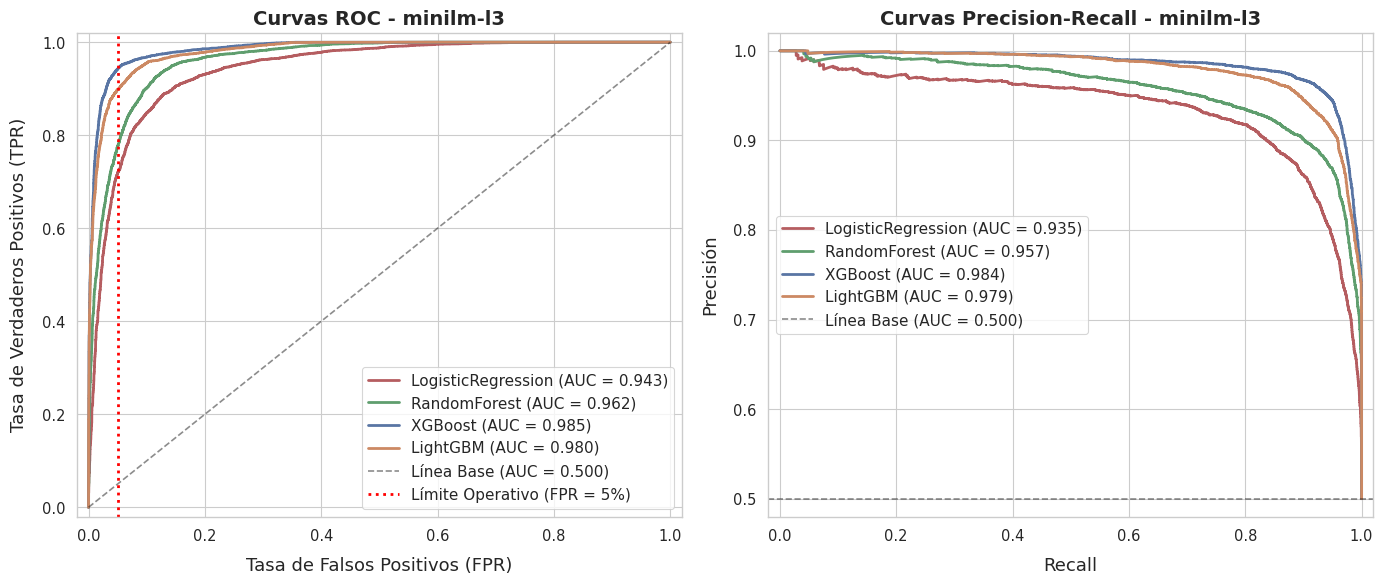

In [ ]:
plot_curvas_roc_pr(resultados, modelo_embedding="gte-small", variante="fused_enriched")
plot_curvas_roc_pr(resultados, modelo_embedding="minilm-l6", variante="fused_enriched")
plot_curvas_roc_pr(resultados, modelo_embedding="minilm-l3", variante="fused_enriched")

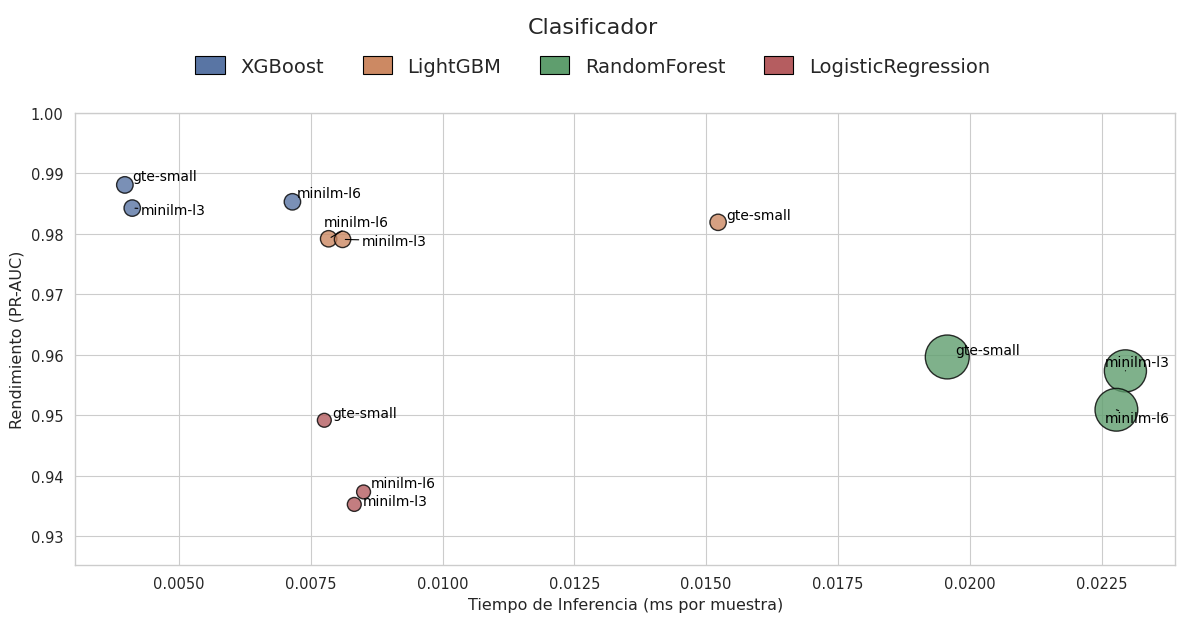

In [ ]:
plot_tradeoff_edge_ai(df_resultados, variante="fused_enriched")

**Estudio de ablación 1 - Estrategias de Representación:**

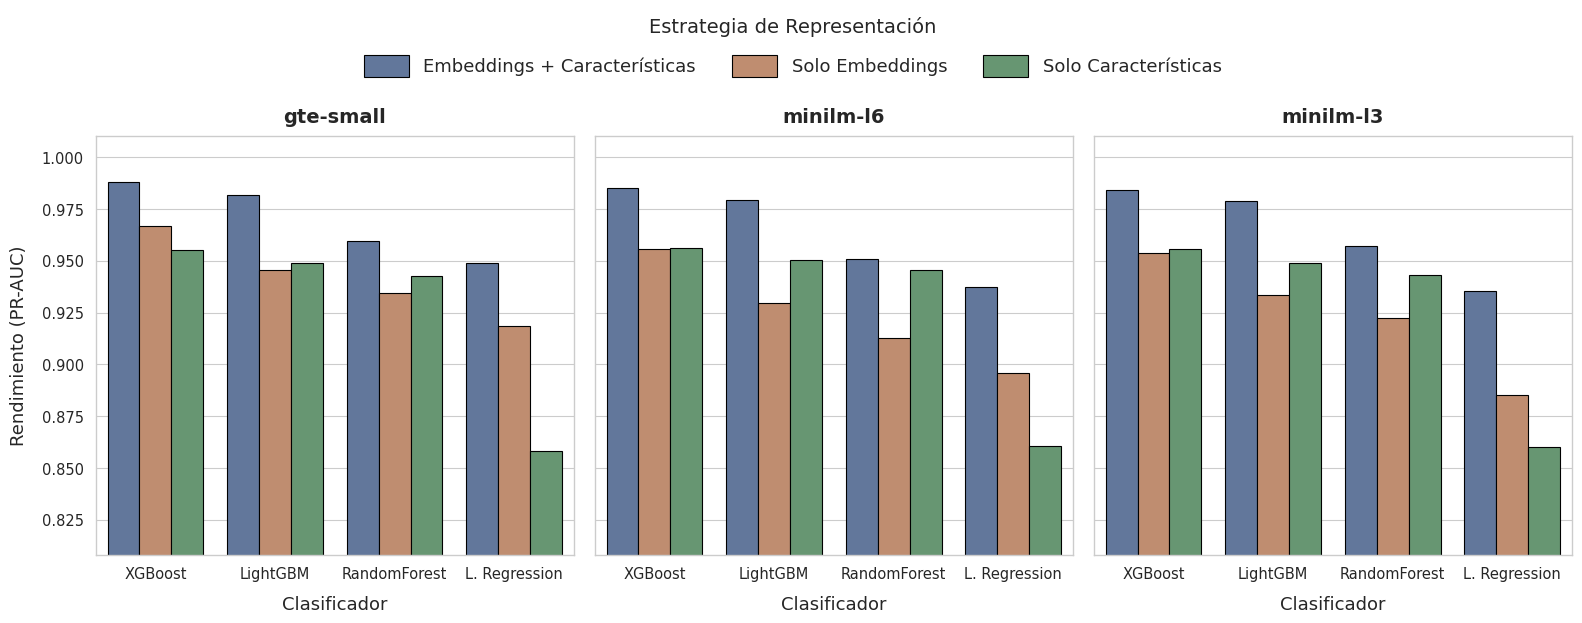

In [35]:
plot_estudio_ablacion(df_resultados, metrica="pr_auc")

**Estudio de ablación 2 - Estrategia sin modelos de embeddings:**

In [36]:
modelo_base = "gte-small"

# Escenario A: Estructurales puras (excluyendo similitud coseno)
X_train_heur_puras = all_embeddings[modelo_base]["features_rel"][idx_train, 1:]
X_test_heur_puras = all_embeddings[modelo_base]["features_rel"][idx_test, 1:]

# Escenario B: Estructurales + Similitud Coseno
X_train_heur_coseno = all_embeddings[modelo_base]["features_rel"][idx_train]
X_test_heur_coseno = all_embeddings[modelo_base]["features_rel"][idx_test]

escenarios = {"Estructurales (sin Similitud Coseno)": (X_train_heur_puras, X_test_heur_puras),
              "Estructurales + Similitud Coseno": (X_train_heur_coseno, X_test_heur_coseno)}

In [37]:
resultados_ablacion_heur = []

# Entrenar y evaluar los cuatro modelos en los dos escenarios
for nombre_escenario, (X_tr, X_te) in escenarios.items():
    print(f"\n--- Evaluando escenario: {nombre_escenario} ---")

    for nombre_clf, clf_template in clasificadores.items():
        # Clonar el modelo para que se entrene desde cero
        clf = clone(clf_template)
        res = evaluar_clasificador(clf, X_tr, y_train, X_te, y_test, nombre_clf)

        # Añadir la etiqueta del escenario y guardarlo
        res["escenario"] = nombre_escenario
        resultados_ablacion_heur.append(res)

        print(f" > {nombre_clf}: PR-AUC = {res['pr_auc']:.4f} | F1 = {res['f1_score']:.4f} | T. Inf = {res['inferencia_ms']:.3f} ms")


--- Evaluando escenario: Estructurales (sin Similitud Coseno) ---
 > LogisticRegression: PR-AUC = 0.8533 | F1 = 0.7563 | T. Inf = 0.001 ms
 > RandomForest: PR-AUC = 0.9248 | F1 = 0.8560 | T. Inf = 0.013 ms
 > XGBoost: PR-AUC = 0.9354 | F1 = 0.8652 | T. Inf = 0.004 ms
 > LightGBM: PR-AUC = 0.9293 | F1 = 0.8580 | T. Inf = 0.008 ms

--- Evaluando escenario: Estructurales + Similitud Coseno ---
 > LogisticRegression: PR-AUC = 0.8582 | F1 = 0.7726 | T. Inf = 0.000 ms
 > RandomForest: PR-AUC = 0.9427 | F1 = 0.8711 | T. Inf = 0.007 ms
 > XGBoost: PR-AUC = 0.9551 | F1 = 0.8891 | T. Inf = 0.004 ms
 > LightGBM: PR-AUC = 0.9489 | F1 = 0.8768 | T. Inf = 0.008 ms


In [38]:
# Tabla comparativa ordenada por mejor PR-AUC
df_ablacion_heur = pd.DataFrame(resultados_ablacion_heur)
cols_mostrar = ["escenario", "clasificador", "accuracy", "f1_score", "roc_auc", "pr_auc", "inferencia_ms", "tamano_mb"]

df_final_ablacion = df_ablacion_heur[cols_mostrar].sort_values(by="pr_auc", ascending=False).round(4)
display(df_final_ablacion)

,escenario,clasificador,accuracy,f1_score,roc_auc,pr_auc,inferencia_ms,tamano_mb
6,Estructurales + Similitud Coseno,XGBoost,0.8874,0.8891,0.9590,0.9551,0.0042,0.3194
7,Estructurales + Similitud Coseno,LightGBM,0.8763,0.8768,0.9526,0.9489,0.0077,0.3302
5,Estructurales + Similitud Coseno,RandomForest,0.8704,0.8711,0.9465,0.9427,0.0072,5.0542
2,Estructurales (sin Similitud Coseno),XGBoost,0.8644,0.8652,0.9401,0.9354,0.0041,0.3250
3,Estructurales (sin Similitud Coseno),LightGBM,0.8586,0.8580,0.9347,0.9293,0.0081,0.3294
1,Estructurales (sin Similitud Coseno),RandomForest,0.8549,0.8560,0.9308,0.9248,0.0132,5.5031
4,Estructurales + Similitud Coseno,LogisticRegression,0.7875,0.7726,0.8682,0.8582,0.0002,0.0014
0,Estructurales (sin Similitud Coseno),LogisticRegression,0.7819,0.7563,0.8606,0.8533,0.0005,0.0014


In [39]:
def plot_ablacion_heuristicas_grid(df_ablacion):
    """
    Genera un panel 2x2 comparando 4 métricas para el Estudio de Ablación de las características heurísticas.
    """
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    metricas = [
        ('accuracy', 'Comparativa de Exactitud', axes[0, 0]),
        ('f1_score', 'Comparativa de F1-Score', axes[0, 1]),
        ('roc_auc', 'Comparativa de ROC-AUC', axes[1, 0]),
        ('pr_auc', 'Comparativa de PR-AUC', axes[1, 1])
    ]

    paleta_escenarios = ['#5f9e6e', '#5975a4']

    for columna, titulo, ax in metricas:
        sns.barplot(data=df_ablacion, x='clasificador', y=columna, hue='escenario',
                    palette=paleta_escenarios, ax=ax, edgecolor='black', linewidth=0.5)

        ax.set_title(titulo, fontweight='bold', fontsize=12)
        ax.set_xlabel("Clasificador")

        nombres_metricas = {'accuracy': 'Exactitud', 'f1_score': 'F1-Score', 'roc_auc': 'ROC-AUC', 'pr_auc': 'PR-AUC'}
        ax.set_ylabel(nombres_metricas.get(columna, columna.upper()))

        # Ajuste dinámico del eje Y
        # y_min = max(0.0, df_ablacion[columna].min() - 0.05)
        ax.set_ylim(0.73, 1.0)

        # Valores sobre las barras
        for p in ax.patches:
            altura = p.get_height()
            if pd.notnull(altura) and altura > 0:
                ax.annotate(f"{altura:.3f}",
                            (p.get_x() + p.get_width() / 2., altura),
                            ha='center', va='bottom',
                            fontsize=9, color='black',
                            xytext=(0, 4),
                            textcoords='offset points')

        # Eliminar leyendas individuales
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    handles, labels = axes[0, 0].get_legend_handles_labels()

    # Leyenda central superior
    fig.legend(handles, labels, title='Estrategia de Representación', loc='upper center', bbox_to_anchor=(0.5, 1.05),
               ncol=2, frameon=False, fontsize=14, title_fontsize=16, handlelength=2.5, handleheight=1.5, labelspacing=1)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    ruta_guardado = os.path.join(RES_GRAPH_DIR, "estudio_ablacion_caracteristicas.png")
    plt.savefig(ruta_guardado, dpi=300, bbox_inches='tight')
    plt.show()

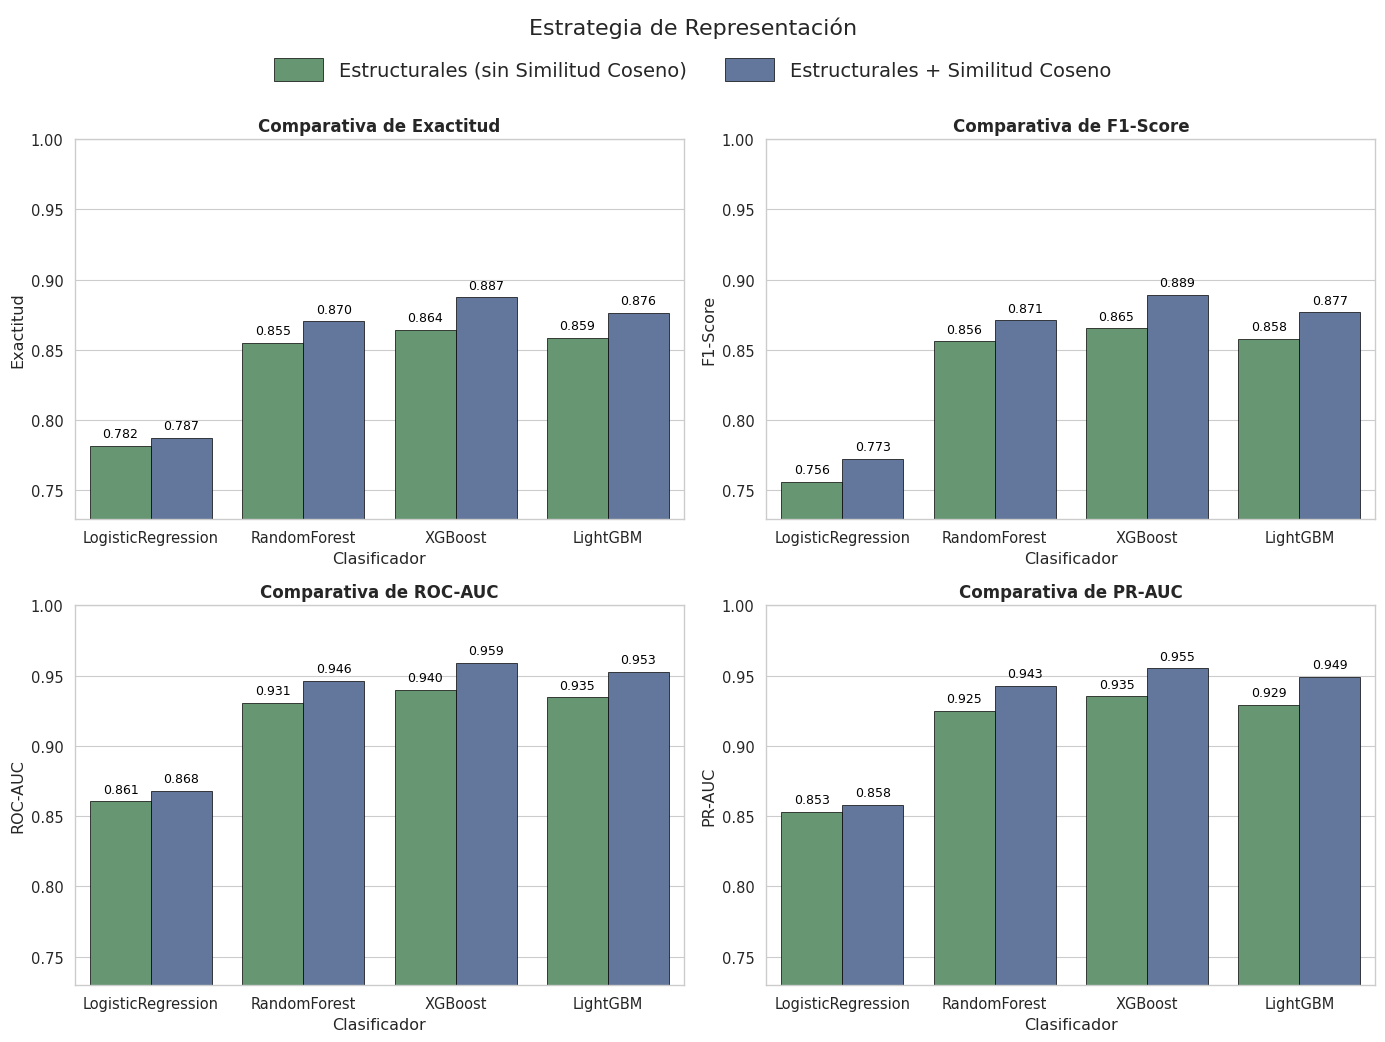

In [40]:
plot_ablacion_heuristicas_grid(df_ablacion_heur)

## **8. Validación y Exportación del Modelo Final**

En esta sección se valida la capacidad de generalización del mejor clasificador mediante una validación cruzada estratificada (K-Fold con 5 particiones) utilizando el conjunto completo de desarrollo (69.000 muestras del conjunto de entrenamiento y test). Posteriormente, se exporta esta configuración para su uso en el entorno de producción simulado.

In [ ]:
target_embedding = "gte-small"
target_variante = "fused_enriched"

# Conjunto completo de datos de experimentación (Train + Test, sin holdout = 69.000 muestras)
X = all_embeddings[target_embedding][target_variante][idx_main]
y = labels_sub[idx_main]
print(f"Tamaño del dataset combinado: {X.shape[0]:,} muestras.")

Tamaño del dataset combinado: 69,000 muestras.


In [ ]:
# Mejor modelo con los parámetros base
xgb_final_eval = XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=SEED, n_jobs=-1)

# Stratified K-Fold (k=5)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Validación cruzada con average_precision (equivale a PR-AUC)
metricas = ['accuracy', 'f1', 'roc_auc', 'average_precision']
cv_results = cross_validate(xgb_final_eval, X, y, cv=skf, scoring=metricas, n_jobs=-1, return_train_score=False)

print("--- Resultados de 5-Fold Cross Validation ---")
print(f"F1-Score: {cv_results['test_f1'].mean():.4f} (+/- {cv_results['test_f1'].std() * 2:.4f})")
print(f"ROC-AUC:  {cv_results['test_roc_auc'].mean():.4f} (+/- {cv_results['test_roc_auc'].std() * 2:.4f})")
print(f"PR-AUC:   {cv_results['test_average_precision'].mean():.4f} (+/- {cv_results['test_average_precision'].std() * 2:.4f})")

--- Resultados de 5-Fold Cross Validation ---
F1-Score: 0.9575 (+/- 0.0024)
ROC-AUC:  0.9904 (+/- 0.0006)
PR-AUC:   0.9889 (+/- 0.0009)


Se entrena el modelo final utilizando los datos de train y test y posteriormente se exporta para su uso en producción:

In [ ]:
# Entrenamiento con todos los datos de experimentación (69k muestras)
xgb_produccion = XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=SEED, n_jobs=-1)
xgb_produccion.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
# Guardar el modelo en Drive
ruta_modelo = os.path.join(MODELS_DIR, "xgb_produccion.pkl")
joblib.dump(xgb_produccion, ruta_modelo)
print(f"Se ha guardado el modelo en {ruta_modelo}")

Se ha guardado el modelo en /content/drive/MyDrive/TFM/models/xgb_produccion.pkl


La segunda parte de este proyecto correspondiente al despliegue del clasificador integrado junto con el modelo pequeño de lenguaje Phi-4-mini y la evaluación automatizada de vulnerabilidades mediante *LLM-as-a-Judge* se encuentra disponible en el siguiente enlace:

[Análisis de Vulnerabilidad y Estrategias de Defensa contra Inyección Indirecta de Prompts en entornos Edge AI (Parte 2/2) - Inferencia](./02_Evaluacion_Produccion.ipynb)